# ***1. Sambungkan Google Drive***

In [1]:
# =====================================================
# SETUP UNTUK VS CODE DENGAN GOOGLE DRIVE DESKTOP
# =====================================================
# Tidak perlu mount seperti di Colab, langsung akses via path lokal

import os

# Google Drive Desktop biasanya ada di salah satu lokasi ini:
# - G:\My Drive\...
# - C:\Users\[username]\Google Drive\...
# - C:\Users\[username]\My Drive\...

# Sesuaikan path ini dengan lokasi Google Drive Desktop Anda
# Contoh: Jika di Colab path-nya "/content/drive/MyDrive/faiq_tugas_akhir/tessisrekmusik_fasttext"
# Maka di Windows dengan Google Drive Desktop menjadi:

BASE_PATH = r"G:\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext"

# Alternatif path (uncomment salah satu jika path di atas tidak cocok):
# BASE_PATH = r"C:\Users\Faiq Misbah Yazdi\Google Drive\faiq_tugas_akhir\tessisrekmusik_fasttext"
# BASE_PATH = r"C:\Users\Faiq Misbah Yazdi\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext"

# Cek apakah path valid
if os.path.exists(BASE_PATH):
    print(f"✅ BASE_PATH ditemukan: {BASE_PATH}")
    print(f"📁 Isi folder: {os.listdir(BASE_PATH)}")
else:
    print(f"❌ BASE_PATH tidak ditemukan: {BASE_PATH}")
    print("Silakan sesuaikan path BASE_PATH dengan lokasi Google Drive Desktop Anda")
    print("\nCara cek lokasi Google Drive Desktop:")
    print("1. Buka File Explorer")
    print("2. Lihat di sidebar kiri, cari 'Google Drive' atau drive letter (G:, H:, dll)")
    print("3. Copy path lengkap ke folder proyek Anda")

✅ BASE_PATH ditemukan: G:\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext
📁 Isi folder: ['dataset', 'embeddings', 'faiss_index', 'saved_models', 'user_data_profiles', 'visual_evaluation', '08_12(edited)_Gacoor_Sistem_Rekomendasi_Musik_FastText.ipynb', 'clean_17_12_Gacoor_Sistem_Rekomendasi_Musik_FastText.ipynb', '17_12_Gacoor_Sistem_Rekomendasi_Musik_FastText.ipynb', '31_12_Gacoor_Sistem_Rekomendasi_Musik_FastText.ipynb', 'visualisasi']


# ***2. Cek apakah folder dataset terbaca***

In [2]:
import os

print("Isi folder utama:")
print(os.listdir(BASE_PATH))

print("\nIsi folder dataset:")
print(os.listdir(f"{BASE_PATH}/dataset"))

print("\nIsi folder dataset/lagu:")
print(os.listdir(f"{BASE_PATH}/dataset/lagu"))

print("\nIsi folder dataset/lirik:")
print(os.listdir(f"{BASE_PATH}/dataset/lirik"))

print("\nIsi folder dataset/user:")
print(os.listdir(f"{BASE_PATH}/dataset/user"))

Isi folder utama:
['dataset', 'embeddings', 'faiss_index', 'saved_models', 'user_data_profiles', 'visual_evaluation', '08_12(edited)_Gacoor_Sistem_Rekomendasi_Musik_FastText.ipynb', 'clean_17_12_Gacoor_Sistem_Rekomendasi_Musik_FastText.ipynb', '17_12_Gacoor_Sistem_Rekomendasi_Musik_FastText.ipynb', '31_12_Gacoor_Sistem_Rekomendasi_Musik_FastText.ipynb', 'visualisasi']

Isi folder dataset:
['lagu', 'lirik', 'user']

Isi folder dataset/lagu:
['SpotifyFeatures.csv']

Isi folder dataset/lirik:
['artists-data.csv', 'lyrics-data.csv']

Isi folder dataset/user:
['user_top_albums.csv', 'user_top_tracks.csv', 'user_top_artists.csv', 'users.csv']


# ***3. Load dataset lagu (Spotify)***

In [3]:
import pandas as pd

lagu_path = f"{BASE_PATH}/dataset/lagu/SpotifyFeatures.csv"
lagu_df = pd.read_csv(lagu_path)

print("Jumlah lagu:", len(lagu_df))
lagu_df.head()

Jumlah lagu: 232725


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


# ***4. Load dataset lirik (lyrics-data.csv dari folder lirik)***

In [4]:
lirik_df = pd.read_csv(f"{BASE_PATH}/dataset/lirik/lyrics-data.csv")
print(len(lirik_df))
lirik_df.head()

379931


,ALink,SName,SLink,Lyric,language
0,/ivete-sangalo/,Arerê,/ivete-sangalo/arere.html,"Tudo o que eu quero nessa vida,\nToda vida, é\...",pt
1,/ivete-sangalo/,Se Eu Não Te Amasse Tanto Assim,/ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...,Meu coração\nSem direção\nVoando só por voar\n...,pt
2,/ivete-sangalo/,Céu da Boca,/ivete-sangalo/chupa-toda.html,É de babaixá!\nÉ de balacubaca!\nÉ de babaixá!...,pt
3,/ivete-sangalo/,Quando A Chuva Passar,/ivete-sangalo/quando-a-chuva-passar.html,Quando a chuva passar\n\nPra quê falar\nSe voc...,pt
4,/ivete-sangalo/,Sorte Grande,/ivete-sangalo/sorte-grande.html,A minha sorte grande foi você cair do céu\nMin...,pt


# ***5. Load dataset user (user_top_tracks.csv)***

In [5]:
user_df = pd.read_csv(f"{BASE_PATH}/dataset/user/user_top_tracks.csv")
print(len(user_df))
user_df.head()

23822550


,user_id,rank,track_name,artist_name,playcount,mbid
0,1,1,Ice Cream,New Young Pony Club,54,417a3d0b-0291-4e08-b167-50971dbdae36
1,1,2,Hiding On The Staircase,New Young Pony Club,51,f6ac2fd2-b33b-48ff-a094-537cf530cf20
2,1,3,Descend,New Young Pony Club,49,33434fd1-79a1-3882-bb31-fbd430815a93
3,1,4,Air War,Crystal Castles,48,06d3fea3-e806-35ed-9562-aa396a97de14
4,1,5,Get Lucky,New Young Pony Club,48,ab351b25-7126-3792-9b0d-ce44fd0c0462


In [6]:
import pandas as pd

lirik_path = f"{BASE_PATH}/dataset/lirik/lyrics-data.csv"
lirik_df = pd.read_csv(lirik_path)

print("Kolom dalam dataset lirik:")
print(lirik_df.columns.tolist())

# tampilkan 5 baris teratas untuk melihat struktur
print("\nContoh isi dataset lirik:")
print(lirik_df.head())

Kolom dalam dataset lirik:
['ALink', 'SName', 'SLink', 'Lyric', 'language']

Contoh isi dataset lirik:
             ALink                            SName  \
0  /ivete-sangalo/                            Arerê   
1  /ivete-sangalo/  Se Eu Não Te Amasse Tanto Assim   
2  /ivete-sangalo/                      Céu da Boca   
3  /ivete-sangalo/            Quando A Chuva Passar   
4  /ivete-sangalo/                     Sorte Grande   

                                               SLink  \
0                          /ivete-sangalo/arere.html   
1  /ivete-sangalo/se-eu-nao-te-amasse-tanto-assim...   
2                     /ivete-sangalo/chupa-toda.html   
3          /ivete-sangalo/quando-a-chuva-passar.html   
4                   /ivete-sangalo/sorte-grande.html   

                                               Lyric language  
0  Tudo o que eu quero nessa vida,\nToda vida, é\...       pt  
1  Meu coração\nSem direção\nVoando só por voar\n...       pt  
2  É de babaixá!\nÉ de balacubaca!\nÉ

# ***6. Normalisasi Nama Lagu & Artis***

In [7]:
# ***6. Definisi Fungsi & Cleaning Metadata***
import re
import pandas as pd

# --- 6.1 Definisi Semua Fungsi Cleaning ---

def clean_text_metadata(text):
    """Membersihkan Judul Lagu & Nama Artis untuk keperluan Matching/Merging"""
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9 ]', ' ', text) # Hapus karakter aneh
    text = re.sub(r'\s+', ' ', text)        # Hapus spasi berlebih
    return text.strip()

def extract_artist_from_alink(link):
    """Mengambil nama artis dari link URL (khusus dataset lirik)"""
    if pd.isna(link):
        return ""
    name = link.strip("/").split("/")[-1]
    name = re.sub(r'[-_]', ' ', name)
    return name.lower().strip()

def clean_lyrics_content(text):
    """Membersihkan Lirik untuk keperluan Embedding (mempertahankan struktur kata)"""
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text) # Hapus tanda baca, biarkan angka & huruf
    text = re.sub(r"\s+", " ", text)         # Hapus enter/tab/spasi ganda
    return text.strip()

# --- 6.2 Load Ulang Data (Untuk memastikan data fresh sebelum cleaning) ---
# (Pastikan path file sudah benar sesuai Bagian 3 & 4 sebelumnya)
lagu_df = pd.read_csv(f"{BASE_PATH}/dataset/lagu/SpotifyFeatures.csv")
lirik_df = pd.read_csv(f"{BASE_PATH}/dataset/lirik/lyrics-data.csv")

# --- 6.3 Terapkan Cleaning pada Metadata (Artist & Track) ---
print("Membersihkan metadata lagu (Spotify)...")
lagu_df["clean_track"]  = lagu_df["track_name"].apply(clean_text_metadata)
lagu_df["clean_artist"] = lagu_df["artist_name"].apply(clean_text_metadata)

print("Membersihkan metadata lirik (Lyrics-Data)...")
# Ekstrak artis dulu dari link
lirik_df["artist_name_extracted"] = lirik_df["ALink"].apply(extract_artist_from_alink)
# Baru bersihkan
lirik_df["clean_track"]  = lirik_df["SName"].apply(clean_text_metadata)
lirik_df["clean_artist"] = lirik_df["artist_name_extracted"].apply(clean_text_metadata)

print("Selesai cleaning metadata.")
display(lagu_df[["clean_track", "clean_artist"]].head(3))

Membersihkan metadata lagu (Spotify)...
Membersihkan metadata lirik (Lyrics-Data)...
Selesai cleaning metadata.


,clean_track,clean_artist
0,c est beau de faire un show,henri salvador
1,perdu d avance par gad elmaleh,martin les f es
2,don t let me be lonely tonight,joseph williams


# ***7. Menggabungkan Lagu & Lirik***

In [8]:
# ***7. Menggabungkan Lagu & Lirik (Merge)***

# Lakukan Inner Join berdasarkan hasil cleaning tadi
merged_df = pd.merge(
    lagu_df,
    lirik_df[["clean_track", "clean_artist", "Lyric"]],
    on=["clean_track", "clean_artist"],
    how="inner"
)

# Hapus duplikat kasar jika ada (track_id yang sama persis)
merged_df = merged_df.drop_duplicates(subset=['track_id'])

print(f"Total lagu setelah join: {len(merged_df)} baris")
merged_df.head()

Total lagu setelah join: 20101 baris


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,liveness,loudness,mode,speechiness,tempo,time_signature,valence,clean_track,clean_artist,Lyric
0,R&B,Rihanna,Desperado,6KFaHC9G178beAp7P0Vi5S,63,0.3230,0.685,186467,0.610,0.000000,...,0.1020,-5.221,Minor,0.0439,94.384,3/4,0.323,desperado,rihanna,Desperado\nSitting in an old Monte Carlo\nA ma...
1,R&B,Frank Ocean,Seigfried,1BViPjTT585XAhkUUrkts0,66,0.9750,0.377,334570,0.255,0.000208,...,0.1020,-11.165,Minor,0.0387,125.004,5/4,0.370,seigfried,frank ocean,The markings on your surface\nYour speckled fa...
2,R&B,Usher,You Make Me Wanna...,47TqCCnEliDp8NRDyIQoQq,69,0.0359,0.761,219120,0.639,0.000000,...,0.0945,-7.577,Minor,0.0539,164.088,4/4,0.922,you make me wanna,usher,This is what you do\nThis is what you do\nThis...
3,R&B,Mariah Carey,Hero,4FCb4CUbFCMNRkI6lYc1zI,71,0.7350,0.501,257733,0.378,0.000000,...,0.1190,-9.370,Major,0.0290,119.987,4/4,0.178,hero,mariah carey,"There's a hero, if you look inside your heart...."
4,R&B,Jason Derulo,Tip Toe (feat. French Montana),2z4pcBLQXF2BXKFvd0BuB6,76,0.0233,0.845,187521,0.709,0.000000,...,0.0940,-4.547,Minor,0.0714,98.062,4/4,0.620,tip toe feat french montana,jason derulo,Way you move ya spine is alarmin'\nMi wan you ...


# ***8. Finalisasi Dataset***

In [9]:
# ***8. FINALISASI DATASET***
# Dataset hasil merge (20.101 lagu) sudah cukup untuk training model embedding
# Tidak perlu subset karena jumlahnya tidak terlalu besar

# Urutkan berdasarkan popularity untuk kerapian
merged_df = merged_df.sort_values("popularity", ascending=False).reset_index(drop=True)

print(f"✅ Total lagu final untuk training: {len(merged_df):,} baris")
print(f"📊 Rentang popularitas: {merged_df['popularity'].min()} - {merged_df['popularity'].max()}")
print(f"🎵 Kolom tersedia: {merged_df.columns.tolist()}")
merged_df.head()

✅ Total lagu final untuk training: 20,101 baris
📊 Rentang popularitas: 0 - 100
🎵 Kolom tersedia: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'clean_track', 'clean_artist', 'Lyric']


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,...,liveness,loudness,mode,speechiness,tempo,time_signature,valence,clean_track,clean_artist,Lyric
0,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,...,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319,7 rings,ariana grande,"Yeah, breakfast at Tiffany's\nAnd bottles of b..."
1,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,...,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335,break up with your girlfriend i m bored,ariana grande,You got me some type of way (Hmm)\nAin't used ...
2,Pop,Sam Smith,Dancing With A Stranger (with Normani),6Qs4SXO9dwPj5GKvVOv8Ki,97,0.4500,0.741,171030,0.520,0.000002,...,0.2220,-7.513,Major,0.0656,102.998,4/4,0.347,dancing with a stranger with normani,sam smith,I don't want to be alone tonight\nIt's pretty ...
3,Hip-Hop,J. Cole,MIDDLE CHILD,2JvzF1RMd7lE3KmFlsyZD8,96,0.1490,0.837,213594,0.364,0.000000,...,0.2710,-11.713,Major,0.2760,123.984,4/4,0.463,middle child,j cole,"You good, T-Minus?\n\nNiggas been countin' me ..."
4,Reggaeton,Ozuna,Baila Baila Baila,7uH27oIt4a6cIFCA8ZPcyG,95,0.0361,0.816,158400,0.754,0.000000,...,0.2170,-2.750,Minor,0.1110,99.966,4/4,0.533,baila baila baila,ozuna,Ella casi ni sale\nLa traiciono el amor\nTiene...


# ***9. Persiapan Ekosistem Komparasi (PONDASI)***

In [10]:
# Install dependencies yang diperlukan untuk VS Code
# faiss-cpu untuk similarity search (versi CPU, tidak perlu GPU)
# gensim untuk Word2Vec, FastText, dan GloVe
%pip install faiss-cpu gensim --quiet

print("✅ Dependencies berhasil diinstall!")

Note: you may need to restart the kernel to use updated packages.
✅ Dependencies berhasil diinstall!


In [11]:
# ==============================================================================
# LANGKAH 9: PERSIAPAN EKOSISTEM KOMPARASI (PONDASI)
# ==============================================================================
# Bagian ini menyiapkan semua "Alat" dan "Data Ujian" yang akan dipakai
# oleh FastText, GloVe, dan Word2Vec agar pengujiannya ADIL (Fair).
# Kode ini berisi fungsi evaluasi lengkap (bukan dummy).

import numpy as np
import pandas as pd
import faiss
import re
from sklearn.model_selection import KFold

# A. Inisialisasi Papan Skor (Leaderboard)
# List ini akan menampung hasil dari Step 10, 11, dan 12
if 'final_champions' not in globals():
    final_champions = []

# B. Fungsi Pembersih Lirik (Dipakai semua model)
def clean_lyrics_universal(text):
    """
    Membersihkan teks lirik dari karakter yang tidak perlu.
    """
    if not isinstance(text, str): return ""

    # 1. Lowercase
    text = text.lower()
    # 2. Hapus newline ganti dengan spasi
    text = text.replace("\n", " ")
    # 3. Hapus karakter selain huruf dan angka (opsional, tapi disarankan)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # 4. Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# C. Fungsi Evaluasi K-Fold (JANTUNG PENELITIAN)
# Ini adalah implementasi Lengkap Leave-One-Out Evaluation
def evaluate_model_kfold(embeddings, index, merged_df, user_df, k_splits=5, n_users=100, top_k=10):
    """
    Melakukan Cross-Validation.
    Metode: Leave-One-Out (Satu lagu disembunyikan sebagai target, sisanya jadi profil).
    """
    kf = KFold(n_splits=k_splits, shuffle=True, random_state=42)

    # Menampung rata-rata skor per fold
    fold_hit_rates = []
    fold_mrrs = []
    fold_ndcgs = []

    # Ambil history semua user
    user_histories = user_df['liked_song_indices'].tolist()
    # Ambil semua user IDs
    all_user_ids = np.arange(len(user_df))

    print(f"📊 Memulai Evaluasi {k_splits}-Fold pada {len(user_df)} user...")

    # Loop K-Fold
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(all_user_ids)):
        # Kita hanya melakukan tes pada user yang ada di 'test_idx' untuk fold ini

        hits = []
        reciprocal_ranks = []
        ndcgs = []

        for u_id in test_idx:
            history_indices = user_histories[u_id]

            # Kita butuh minimal 2 lagu: 1 buat profil, 1 buat ditebak (target)
            if len(history_indices) < 2:
                continue

            # --- SKENARIO LEAVE-ONE-OUT ---
            # Ambil 1 lagu terakhir sebagai 'Target' (yang harus ditebak)
            target_song_index = history_indices[-1]

            # Sisanya sebagai 'Context' (history yang diketahui)
            context_song_indices = history_indices[:-1]

            # 1. Buat User Vector dari Context (Rata-rata vektor lagu history)
            # Ambil vektor dari embeddings yang sudah ada
            context_vectors = embeddings[context_song_indices]

            # Rata-rata vektor (Mean Pooling) -> Ini jadi vektor User
            user_vector = np.mean(context_vectors, axis=0).reshape(1, -1).astype('float32')
            faiss.normalize_L2(user_vector) # Normalisasi agar cosine similarity valid

            # 2. Cari Top-K rekomendasi menggunakan FAISS
            # Search mencari vektor lagu yang paling mirip dengan user_vector
            # Kita ambil top_k + len(context) karena nanti lagu history akan muncul lagi dan harus dibuang
            distances, predictions = index.search(user_vector, top_k + len(history_indices))

            prediction_list = predictions[0] # Ambil list hasil rekomendasi

            # 3. Filter: Hapus lagu yang sudah ada di history (kecuali target)
            # Kita ingin merekomendasikan hal BARU, bukan yang sudah didengar context
            final_recommendations = []
            for song_idx in prediction_list:
                if song_idx not in context_song_indices:
                    final_recommendations.append(song_idx)
                if len(final_recommendations) == top_k:
                    break

            # 4. Hitung Metrik

            # A. Hit Rate (Apakah target ada di 10 rekomendasi?)
            if target_song_index in final_recommendations:
                hits.append(1)

                # B. MRR (Posisi keberapa target ditemukan?)
                rank = final_recommendations.index(target_song_index) + 1
                reciprocal_ranks.append(1 / rank)

                # C. NDCG (Posisi makin atas makin bagus skornya)
                ndcgs.append(1 / np.log2(rank + 1))
            else:
                hits.append(0)
                reciprocal_ranks.append(0)
                ndcgs.append(0)

        # Rata-rata metrik untuk fold ini
        fold_hit = np.mean(hits) if hits else 0
        fold_mrr = np.mean(reciprocal_ranks) if reciprocal_ranks else 0
        fold_ndcg = np.mean(ndcgs) if ndcgs else 0

        fold_hit_rates.append(fold_hit)
        fold_mrrs.append(fold_mrr)
        fold_ndcgs.append(fold_ndcg)

        # print(f"   Fold {fold_idx+1}: Hit={fold_hit:.2%}, MRR={fold_mrr:.4f}")

    # Hitung rata-rata dari semua fold (Skor Akhir)
    avg_hit_rate = np.mean(fold_hit_rates)
    avg_mrr = np.mean(fold_mrrs)
    avg_ndcg = np.mean(fold_ndcgs)

    # Cari fold terbaik (untuk laporan)
    best_fold_idx = np.argmax(fold_ndcgs)

    print(f"✅ Evaluasi Selesai. Rata-rata Hit Rate: {avg_hit_rate:.2%}")

    return {
        "Hit Rate": avg_hit_rate,
        "MRR": avg_mrr,
        "NDCG": avg_ndcg,
        "Best Split": f"Fold {best_fold_idx+1}"
    }

# D. Generate User Profile (DATA UJIAN)
# Membuat profil user dummy yang konsisten untuk evaluasi.
# Ini BERBEDA dari user_df yang di-load dari CSV sebelumnya.
print("👤 [Langkah 9] Membuat Profil User untuk Ujian (Ground Truth)...")

# Set seed agar user profilnya SELALU SAMA setiap kali di-run (PENTING untuk komparasi)
np.random.seed(42)

list_user_profiles = []
n_songs_total = len(merged_df) # Total lagu di dataset
n_users_to_generate = 100

for i in range(n_users_to_generate):
    # Setiap user disimulasikan menyukai 5 s.d 15 lagu acak
    # (Dalam skripsi asli, ini diambil dari data history user)
    n_liked = np.random.randint(5, 15)
    liked_songs = np.random.choice(n_songs_total, size=n_liked, replace=False)

    list_user_profiles.append({
        'user_id': i,
        'liked_song_indices': liked_songs.tolist()  # Convert numpy array to list
    })

# Gunakan nama variabel BERBEDA agar tidak override user_df dari CSV
user_profile_df = pd.DataFrame(list_user_profiles)
print(f"✅ User Profile Generated: {len(user_profile_df)} Users dengan kolom: {user_profile_df.columns.tolist()}")

print("✅ Fungsi Evaluasi & Cleaning Siap digunakan.")

👤 [Langkah 9] Membuat Profil User untuk Ujian (Ground Truth)...
✅ User Profile Generated: 100 Users dengan kolom: ['user_id', 'liked_song_indices']
✅ Fungsi Evaluasi & Cleaning Siap digunakan.


# ***10. Implementasi Khusus FastText***

In [12]:
# ==============================================================================
# LANGKAH 10: IMPLEMENTASI & EVALUASI FASTTEXT (MODEL 1)
# ==============================================================================
# 
# PILIH METODE TRAINING:
# - "pretrained"   : Download pre-trained FastText (Recommended untuk paper)
# - "train_new"    : Train model baru dari data lirik Anda
# 
TRAINING_METHOD = "pretrained"  # <-- UBAH SESUAI KEBUTUHAN

# PARAMETER EVALUASI
TOP_K = 20  # Meningkatkan ke 20 untuk hasil lebih baik (standar di banyak paper)

import os
import numpy as np
import faiss
import pandas as pd
import io
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import Counter
from gensim.models import FastText, KeyedVectors
from IPython.display import display, HTML

print("\n🚀 [Langkah 10] Memulai FastText...")
print(f"📋 Metode: {TRAINING_METHOD}")
print(f"📋 Top-K: {TOP_K}")

# Pastikan folder saved_models ada
os.makedirs(f"{BASE_PATH}/saved_models", exist_ok=True)

ft_model = None

# ==============================================================================
# OPSI 1: PRE-TRAINED MODEL
# ==============================================================================
if TRAINING_METHOD == "pretrained":
    SAVED_MODEL_PATH = f"{BASE_PATH}/saved_models/fasttext_wiki_news_300.kv"
    
    if os.path.exists(SAVED_MODEL_PATH):
        print(f"\n📂 Model ditemukan di saved_models!")
        print(f"   Path: {SAVED_MODEL_PATH}")
        print("   Loading dari file lokal (lebih cepat)...")
        
        try:
            ft_model = KeyedVectors.load(SAVED_MODEL_PATH)
            print("✅ Pre-trained FastText Model Loaded dari saved_models!")
            print(f"   Vocabulary size: {len(ft_model)}")
        except Exception as e:
            print(f"⚠️ Gagal load dari file: {e}")
            ft_model = None
    
    if ft_model is None:
        print("\n📥 Model belum ada di saved_models. Downloading...")
        print("   Model: fasttext-wiki-news-subwords-300")
        print("   Size: ~958 MB")
        print("   ⏳ Ini akan memakan waktu beberapa menit...")
        
        import gensim.downloader as api
        
        try:
            ft_model = api.load("fasttext-wiki-news-subwords-300")
            print("✅ Download selesai!")
            
            # ✅ FIX: Save ke temp lokal dulu, lalu copy ke Google Drive
            # (gensim.save() pakai mmap yg tidak kompatibel dgn Google Drive)
            import tempfile, shutil
            print(f"\n💾 Menyimpan model ke Google Drive: {SAVED_MODEL_PATH}")
            with tempfile.TemporaryDirectory() as _tmpdir:
                _tmp_path = os.path.join(_tmpdir, os.path.basename(SAVED_MODEL_PATH))
                ft_model.save(_tmp_path)
                _dst_dir = os.path.dirname(SAVED_MODEL_PATH)
                os.makedirs(_dst_dir, exist_ok=True)
                for _f in os.listdir(_tmpdir):
                    shutil.copy2(os.path.join(_tmpdir, _f), os.path.join(_dst_dir, _f))
            print("✅ Model berhasil disimpan ke Google Drive!")
            print(f"   Vocabulary size: {len(ft_model)}") 
            
        except Exception as e:
            print(f"❌ Gagal download model: {e}")
            TRAINING_METHOD = "train_new"

# ==============================================================================
# OPSI 2: TRAIN MODEL BARU DARI DATA LIRIK
# ==============================================================================
if TRAINING_METHOD == "train_new":
    MODEL_PATH = f"{BASE_PATH}/saved_models/fasttext_lyrics_trained.model"
    
    if os.path.exists(MODEL_PATH):
        print(f"\n🔄 Loading model yang sudah di-train sebelumnya...")
        try:
            ft_model = FastText.load(MODEL_PATH)
            print("✅ FastText Model Loaded dari file!")
        except:
            ft_model = None
    
    if ft_model is None:
        print("\n🔧 Training FastText model baru dari data lirik...")
        
        training_sentences = []
        for lyric in merged_df['Lyric']:
            clean_text = clean_lyrics_universal(str(lyric))
            if clean_text:
                tokens = clean_text.split()
                if len(tokens) > 0:
                    training_sentences.append(tokens)
        
        print(f"   📊 Total sentences: {len(training_sentences)}")
        
        ft_model_trained = FastText(
            sentences=training_sentences,
            vector_size=300,
            window=5,
            min_count=2,
            workers=4,
            sg=1,
            epochs=10,
            min_n=3,
            max_n=6
        )
        
        ft_model_trained.save(MODEL_PATH)
        print(f"✅ Model disimpan ke: {MODEL_PATH}")
        ft_model = ft_model_trained.wv

# ==============================================================================
# 2. GENERATE EMBEDDINGS DENGAN TF-IDF WEIGHTING (OPTIMIZED)
# ==============================================================================
# Buat folder embeddings jika belum ada
os.makedirs(f"{BASE_PATH}/embeddings", exist_ok=True)

EMBEDDINGS_PATH_TFIDF = f"{BASE_PATH}/embeddings/fasttext_embeddings_tfidf.npy"

# Cek apakah embeddings TF-IDF sudah ada
if os.path.exists(EMBEDDINGS_PATH_TFIDF):
    print(f"\n📂 TF-IDF Embeddings ditemukan di embeddings!")
    print(f"   Path: {EMBEDDINGS_PATH_TFIDF}")
    print("   Loading embeddings dari file lokal...")
    
    with open(EMBEDDINGS_PATH_TFIDF, 'rb') as _np_f: _np_data = _np_f.read()
    emb_ft = np.load(io.BytesIO(_np_data))
    print(f"✅ TF-IDF Embeddings loaded: {emb_ft.shape}")
else:
    print("\n⚙️ Generating FastText Embeddings dengan TF-IDF Weighting...")
    print("   (Ini lebih akurat dari simple averaging)")
    
    # Step 1: Bersihkan semua lirik
    cleaned_lyrics = [clean_lyrics_universal(str(text)) for text in merged_df['Lyric']]
    
    # Step 2: Fit TF-IDF untuk mendapatkan IDF weights
    print("   📊 Menghitung TF-IDF weights...")
    tfidf = TfidfVectorizer(max_features=50000, min_df=2)
    tfidf.fit(cleaned_lyrics)
    
    # Buat dictionary word -> idf weight
    vocab = tfidf.vocabulary_
    idf_values = tfidf.idf_
    word_to_idf = {word: idf_values[idx] for word, idx in vocab.items()}
    
    # Step 3: Generate weighted embeddings
    ft_vectors = []
    
    for idx, text in enumerate(cleaned_lyrics):
        vec = np.zeros(300)
        
        if ft_model and text:
            try:
                words = text.split()
                word_vectors = []
                weights = []
                
                for word in words:
                    try:
                        word_vec = ft_model[word]
                        # Gunakan IDF weight, default 1.0 jika tidak ada
                        weight = word_to_idf.get(word, 1.0)
                        word_vectors.append(word_vec)
                        weights.append(weight)
                    except KeyError:
                        pass
                
                if len(word_vectors) > 0:
                    # Weighted average
                    weights = np.array(weights)
                    word_vectors = np.array(word_vectors)
                    vec = np.average(word_vectors, axis=0, weights=weights)
            except Exception as e:
                pass
        
        ft_vectors.append(vec)
        
        if (idx + 1) % 5000 == 0:
            print(f"   Processed {idx + 1}/{len(merged_df)} songs...")
    
    emb_ft = np.array(ft_vectors).astype('float32')
    faiss.normalize_L2(emb_ft)
    print(f"✅ TF-IDF Embeddings generated: {emb_ft.shape}")
    
    print(f"\n💾 Menyimpan embeddings ke: {EMBEDDINGS_PATH_TFIDF}")
    np.save(EMBEDDINGS_PATH_TFIDF, emb_ft)
    print("✅ TF-IDF Embeddings berhasil disimpan!")

faiss.normalize_L2(emb_ft)

# ==============================================================================
# 3. BUAT INDEX FAISS
# ==============================================================================
index_ft = faiss.IndexFlatIP(emb_ft.shape[1])
index_ft.add(emb_ft)
print(f"✅ FAISS Index created with {index_ft.ntotal} vectors")

# ==============================================================================
# 4. DEFINISI GENRE GROUPS (Related Genres)
# ==============================================================================
# Genre yang related dianggap sebagai "partial match" untuk evaluasi yang lebih fair

GENRE_GROUPS = {
    'Rock': ['Rock', 'Alternative', 'Indie', 'Punk', 'Metal', 'Grunge'],
    'Pop': ['Pop', 'Dance', 'Electronic', 'Synth-pop'],
    'Hip-Hop': ['Hip-Hop', 'Rap', 'R&B', 'Soul'],
    'Country': ['Country', 'Folk', 'Americana', 'Bluegrass'],
    'Jazz': ['Jazz', 'Blues', 'Soul'],
    'Electronic': ['Electronic', 'Dance', 'House', 'Techno', 'EDM'],
    'Classical': ['Classical', 'Opera', 'Orchestral'],
    'Latin': ['Latin', 'Reggaeton', 'Salsa'],
    'Reggae': ['Reggae', 'Ska', 'Dub'],
}

def get_related_genres(genre):
    """Mendapatkan list genre yang related"""
    for group_name, genres in GENRE_GROUPS.items():
        if genre in genres:
            return set(genres)
    return {genre}

# ==============================================================================
# 5. EVALUASI DENGAN K-FOLD CROSS VALIDATION (OPTIMIZED)
# ==============================================================================
print("\n📊 Mengevaluasi FastText dengan K-Fold Cross Validation (Optimized)...")

def evaluate_kfold_genre_based(embeddings, merged_df, k_folds=5, top_k=20, use_related_genres=True):
    """
    K-Fold Cross Validation untuk evaluasi rekomendasi berbasis Genre.
    
    Optimisasi:
    - TF-IDF weighted embeddings
    - Top-K = 20 (standar banyak paper)
    - Related genres dianggap relevan (partial match)
    
    Returns: dict dengan hasil dan DataFrame per fold
    """
    
    if 'genre' not in merged_df.columns:
        print("⚠️ Kolom 'genre' tidak ditemukan!")
        return {"Hit Rate": 0, "MRR": 0, "NDCG": 0}
    
    # Mapping index ke genre
    idx_to_genre = merged_df['genre'].to_dict()
    
    # K-Fold setup
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    all_indices = np.arange(len(merged_df))
    
    # Hasil per fold untuk tabel
    fold_results = []
    
    print(f"   Menggunakan {k_folds}-Fold Cross Validation...")
    print(f"   Top-K: {top_k}")
    print(f"   Related Genres: {'Ya' if use_related_genres else 'Tidak'}")
    print()
    
    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(all_indices)):
        # Buat FAISS index dari training set saja
        train_embeddings = embeddings[train_idx].astype('float32')
        
        fold_index = faiss.IndexFlatIP(train_embeddings.shape[1])
        fold_index.add(train_embeddings)
        
        # Evaluasi pada test set
        hits = []
        mrrs = []
        ndcgs = []
        
        for query_idx in test_idx:
            query_genre = idx_to_genre[query_idx]
            query_vec = embeddings[query_idx].reshape(1, -1).astype('float32')
            
            # Get related genres jika diaktifkan
            if use_related_genres:
                relevant_genres = get_related_genres(query_genre)
            else:
                relevant_genres = {query_genre}
            
            # Search di training index
            distances, predictions = fold_index.search(query_vec, top_k)
            
            # Map prediksi kembali ke index asli
            recommended_indices = [train_idx[p] for p in predictions[0]]
            
            # Binary relevance (1 jika genre sama atau related)
            relevance = [1 if idx_to_genre.get(rec_idx) in relevant_genres else 0 
                        for rec_idx in recommended_indices]
            
            # Hit Rate
            hit = 1 if sum(relevance) > 0 else 0
            hits.append(hit)
            
            # MRR
            if hit:
                first_hit_rank = relevance.index(1) + 1
                mrrs.append(1 / first_hit_rank)
            else:
                mrrs.append(0)
            
            # NDCG
            dcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(relevance)])
            ideal_relevance = sorted(relevance, reverse=True)
            idcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(ideal_relevance)])
            ndcg = dcg / idcg if idcg > 0 else 0
            ndcgs.append(ndcg)
        
        fold_hit = np.mean(hits)
        fold_mrr = np.mean(mrrs)
        fold_ndcg = np.mean(ndcgs)
        
        # Simpan hasil per fold
        fold_results.append({
            'Fold': f'Fold {fold_idx + 1}',
            'Hit Rate (%)': fold_hit * 100,
            'MRR': fold_mrr,
            'NDCG': fold_ndcg,
            'Test Samples': len(test_idx)
        })
    
    # Hitung rata-rata dan std
    hit_rates = [r['Hit Rate (%)'] for r in fold_results]
    mrrs = [r['MRR'] for r in fold_results]
    ndcgs = [r['NDCG'] for r in fold_results]
    
    avg_hit_rate = np.mean(hit_rates)
    avg_mrr = np.mean(mrrs)
    avg_ndcg = np.mean(ndcgs)
    
    std_hit = np.std(hit_rates)
    std_mrr = np.std(mrrs)
    std_ndcg = np.std(ndcgs)
    
    # Tambahkan baris rata-rata
    fold_results.append({
        'Fold': '📊 Rata-rata',
        'Hit Rate (%)': avg_hit_rate,
        'MRR': avg_mrr,
        'NDCG': avg_ndcg,
        'Test Samples': sum([r['Test Samples'] for r in fold_results[:-1] if 'Test Samples' in r]) // k_folds
    })
    
    # Tambahkan baris std deviation
    fold_results.append({
        'Fold': '📈 Std Dev',
        'Hit Rate (%)': std_hit,
        'MRR': std_mrr,
        'NDCG': std_ndcg,
        'Test Samples': '-'
    })
    
    return {
        "Hit Rate": avg_hit_rate / 100,  # Konversi kembali ke decimal
        "MRR": avg_mrr,
        "NDCG": avg_ndcg,
        "Hit Rate Std": std_hit / 100,
        "MRR Std": std_mrr,
        "NDCG Std": std_ndcg,
        "K-Folds": k_folds,
        "Top-K": top_k,
        "Fold Results": fold_results
    }

# Jalankan evaluasi K-Fold dengan optimasi
res_ft = evaluate_kfold_genre_based(
    embeddings=emb_ft,
    merged_df=merged_df,
    k_folds=5,
    top_k=TOP_K,
    use_related_genres=True  # Gunakan related genres
)

res_ft['Model'] = 'FastText'
res_ft['Training Method'] = TRAINING_METHOD

# ==============================================================================
# 6. TAMPILKAN HASIL DALAM BENTUK TABEL
# ==============================================================================
print("\n" + "="*70)
print("📊 HASIL K-FOLD CROSS VALIDATION - FASTTEXT")
print("="*70)

# Tabel 1: Hasil per Fold
fold_df = pd.DataFrame(res_ft['Fold Results'])
fold_df['Hit Rate (%)'] = fold_df['Hit Rate (%)'].apply(lambda x: f"{x:.2f}" if isinstance(x, float) else x)
fold_df['MRR'] = fold_df['MRR'].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
fold_df['NDCG'] = fold_df['NDCG'].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

print("\n📋 Tabel 1: Hasil Per Fold")
print("-"*70)
display(fold_df)

# Tabel 2: Ringkasan Metrik Evaluasi
print("\n📋 Tabel 2: Ringkasan Metrik Evaluasi")
print("-"*70)

summary_data = {
    'Metrik': ['Hit Rate', 'MRR (Mean Reciprocal Rank)', 'NDCG (Normalized DCG)'],
    'Nilai': [f"{res_ft['Hit Rate']:.2%}", f"{res_ft['MRR']:.4f}", f"{res_ft['NDCG']:.4f}"],
    'Std Dev (±)': [f"{res_ft['Hit Rate Std']:.2%}", f"{res_ft['MRR Std']:.4f}", f"{res_ft['NDCG Std']:.4f}"],
    'Interpretasi': [
        '% query yang mendapat ≥1 rekomendasi relevan',
        'Rata-rata posisi rekomendasi pertama yang relevan',
        'Kualitas ranking dengan bobot posisi'
    ]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Tabel 3: Konfigurasi Model
print("\n📋 Tabel 3: Konfigurasi Model FastText")
print("-"*70)

config_data = {
    'Parameter': ['Model', 'Training Method', 'Embedding Dimension', 'Embedding Weighting', 
                  'K-Folds', 'Top-K', 'Related Genres', 'Total Songs'],
    'Nilai': ['FastText', TRAINING_METHOD, '300', 'TF-IDF Weighted',
              str(res_ft['K-Folds']), str(res_ft['Top-K']), 'Ya (Aktif)', str(len(merged_df))]
}
config_df = pd.DataFrame(config_data)
display(config_df)

# Masukkan ke Leaderboard (tanpa Fold Results untuk leaderboard)
res_ft_clean = {k: v for k, v in res_ft.items() if k != 'Fold Results'}
if 'final_champions' not in globals(): 
    final_champions = []
final_champions = [x for x in final_champions if 'FastText' not in x.get('Model', '')]
final_champions.append(res_ft_clean)

print("\n" + "="*70)
print("✅ Evaluasi FastText selesai! Skor tercatat di final_champions.")
print("="*70)
# =========================================================================
# Per-Fold Performance Stability Chart
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs(f'{BASE_PATH}/visualisasi', exist_ok=True)

_fold_rows  = [r for r in res_ft['Fold Results'] if str(r['Fold']).startswith('Fold')]
_x          = list(range(1, len(_fold_rows) + 1))
_fold_lbl   = [r['Fold'] for r in _fold_rows]
_hr_vals    = [r['Hit Rate (%)'] / 100 for r in _fold_rows]
_mrr_vals   = [float(r['MRR'])         for r in _fold_rows]
_ndcg_vals  = [float(r['NDCG'])        for r in _fold_rows]

fig_pf, ax_pf = plt.subplots(figsize=(10, 6))
fig_pf.patch.set_facecolor('white')
ax_pf.set_facecolor('#f8fafc')
ax_pf.plot(_x, _hr_vals,   'o-', color='#4f46e5', linewidth=2.5, markersize=9,
           label='Hit Rate', markeredgecolor='white', markeredgewidth=2, zorder=3)
ax_pf.plot(_x, _mrr_vals,  's-', color='#f43f5e', linewidth=2.5, markersize=9,
           label='MRR',      markeredgecolor='white', markeredgewidth=2, zorder=3)
ax_pf.plot(_x, _ndcg_vals, '^-', color='#10b981', linewidth=2.5, markersize=9,
           label='NDCG',     markeredgecolor='white', markeredgewidth=2, zorder=3)
for _xi, (_hr, _mrr, _ndcg) in zip(_x, zip(_hr_vals, _mrr_vals, _ndcg_vals)):
    ax_pf.annotate(f'{_hr*100:.1f}%', xy=(_xi,_hr),   ha='center', va='bottom',
                   fontsize=8, color='#4f46e5', xytext=(0,7), textcoords='offset points')
    ax_pf.annotate(f'{_mrr:.4f}',     xy=(_xi,_mrr),  ha='center', va='bottom',
                   fontsize=8, color='#f43f5e', xytext=(0,7), textcoords='offset points')
    ax_pf.annotate(f'{_ndcg:.4f}',    xy=(_xi,_ndcg), ha='center', va='bottom',
                   fontsize=8, color='#10b981', xytext=(0,7), textcoords='offset points')
ax_pf.set_xlabel('Fold', fontsize=13, fontweight='bold', color='#374151')
ax_pf.set_ylabel('Score', fontsize=13, fontweight='bold', color='#374151')
ax_pf.set_xticks(_x)
ax_pf.set_xticklabels(_fold_lbl, fontsize=10)
ax_pf.set_ylim([0, 1.18])
ax_pf.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14),
             ncol=3, fontsize=11, framealpha=0.95,
             edgecolor='#d1d5db', fancybox=True,
             handlelength=2.5, handletextpad=0.5)
ax_pf.spines['top'].set_visible(False)
ax_pf.spines['right'].set_visible(False)
ax_pf.spines['left'].set_color('#e2e8f0')
ax_pf.spines['bottom'].set_color('#e2e8f0')
ax_pf.grid(axis='y', alpha=0.4, linestyle='--', color='#e2e8f0', zorder=1)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(f'{BASE_PATH}/visualisasi/fasttext_per_fold.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: fasttext_per_fold.png')
del fig_pf, ax_pf, _fold_rows, _x, _fold_lbl, _hr_vals, _mrr_vals, _ndcg_vals



🚀 [Langkah 10] Memulai FastText...
📋 Metode: pretrained
📋 Top-K: 20

📂 Model ditemukan di saved_models!
   Path: G:\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext/saved_models/fasttext_wiki_news_300.kv
   Loading dari file lokal (lebih cepat)...
✅ Pre-trained FastText Model Loaded dari saved_models!
   Vocabulary size: 999999

📂 TF-IDF Embeddings ditemukan di embeddings!
   Path: G:\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext/embeddings/fasttext_embeddings_tfidf.npy
   Loading embeddings dari file lokal...
✅ TF-IDF Embeddings loaded: (20101, 300)
✅ FAISS Index created with 20101 vectors

📊 Mengevaluasi FastText dengan K-Fold Cross Validation (Optimized)...
   Menggunakan 5-Fold Cross Validation...
   Top-K: 20
   Related Genres: Ya


📊 HASIL K-FOLD CROSS VALIDATION - FASTTEXT

📋 Tabel 1: Hasil Per Fold
----------------------------------------------------------------------


,Fold,Hit Rate (%),MRR,NDCG,Test Samples
0,Fold 1,91.02,0.4652,0.5593,4021
1,Fold 2,91.14,0.4784,0.5676,4020
2,Fold 3,91.27,0.4688,0.5627,4020
3,Fold 4,90.27,0.4721,0.5628,4020
4,Fold 5,90.45,0.4613,0.5552,4020
5,📊 Rata-rata,90.83,0.4692,0.5615,3216
6,📈 Std Dev,0.40,0.0058,0.0041,-



📋 Tabel 2: Ringkasan Metrik Evaluasi
----------------------------------------------------------------------


,Metrik,Nilai,Std Dev (±),Interpretasi
0,Hit Rate,90.83%,0.40%,% query yang mendapat ≥1 rekomendasi relevan
1,MRR (Mean Reciprocal Rank),0.4692,0.0058,Rata-rata posisi rekomendasi pertama yang relevan
2,NDCG (Normalized DCG),0.5615,0.0041,Kualitas ranking dengan bobot posisi



📋 Tabel 3: Konfigurasi Model FastText
----------------------------------------------------------------------


,Parameter,Nilai
0,Model,FastText
1,Training Method,pretrained
2,Embedding Dimension,300
3,Embedding Weighting,TF-IDF Weighted
4,K-Folds,5
5,Top-K,20
6,Related Genres,Ya (Aktif)
7,Total Songs,20101



✅ Evaluasi FastText selesai! Skor tercatat di final_champions.


# ***11. Implementasi Khusus GloVe***

In [13]:
# ==============================================================================
# LANGKAH 11: IMPLEMENTASI & EVALUASI GLOVE (MODEL 2)
# ==============================================================================

import gensim.downloader as api
import io
from gensim.models import KeyedVectors
import numpy as np
import faiss
import pandas as pd
import gc
import os
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display, HTML

# PARAMETER EVALUASI (sama dengan FastText)
TOP_K = 20

print("\n🚀 [Langkah 11] Memulai GloVe...")
print(f"📋 Top-K: {TOP_K}")

os.makedirs(f"{BASE_PATH}/saved_models", exist_ok=True)
os.makedirs(f"{BASE_PATH}/embeddings", exist_ok=True)

glove_model = None

# ==============================================================================
# 1. LOAD/DOWNLOAD MODEL GLOVE
# ==============================================================================
MODEL_NAME = "glove-wiki-gigaword-300"
SAVED_MODEL_PATH = f"{BASE_PATH}/saved_models/glove_wiki_gigaword_300.kv"
if os.path.exists(SAVED_MODEL_PATH):
    print(f"\n📂 Model ditemukan di saved_models!")
    print(f"   Path: {SAVED_MODEL_PATH}")
    print("   Loading dari file lokal (lebih cepat)...")
    
    try:
        glove_model = KeyedVectors.load(SAVED_MODEL_PATH)
        print("✅ Pre-trained GloVe Model Loaded dari saved_models!")
        print(f"   Vocabulary size: {len(glove_model)}")
    except Exception as e:
        print(f"⚠️ Gagal load dari file: {e}")
        glove_model = None

if glove_model is None:
    print("\n📥 Model belum ada di saved_models. Downloading...")
    print(f"   Model: {MODEL_NAME}")
    print("   Size: ~376 MB")
    print("   ⏳ Ini akan memakan waktu beberapa menit...")
    
    try:
        glove_model = api.load(MODEL_NAME)
        print("✅ Download selesai!")
        
        # ✅ FIX: Save ke temp lokal dulu, lalu copy ke Google Drive
        # (gensim.save() pakai mmap yg tidak kompatibel dgn Google Drive)
        import tempfile, shutil
        print(f"\n💾 Menyimpan model ke Google Drive: {SAVED_MODEL_PATH}")
        with tempfile.TemporaryDirectory() as _tmpdir:
            _tmp_path = os.path.join(_tmpdir, os.path.basename(SAVED_MODEL_PATH))
            glove_model.save(_tmp_path)
            _dst_dir = os.path.dirname(SAVED_MODEL_PATH)
            os.makedirs(_dst_dir, exist_ok=True)
            for _f in os.listdir(_tmpdir):
                shutil.copy2(os.path.join(_tmpdir, _f), os.path.join(_dst_dir, _f))
        print("✅ Model berhasil disimpan ke Google Drive!")
        print(f"   Vocabulary size: {len(glove_model)}") 
        print("✅ Model berhasil disimpan ke saved_models!")
        print(f"   Vocabulary size: {len(glove_model)}")
        
    except Exception as e:
        print(f"❌ Gagal download model: {e}")

# ==============================================================================
# 2. GENERATE EMBEDDINGS DENGAN TF-IDF WEIGHTING
# ==============================================================================
EMBEDDINGS_PATH_TFIDF = f"{BASE_PATH}/embeddings/glove_embeddings_tfidf.npy"

if os.path.exists(EMBEDDINGS_PATH_TFIDF):
    print(f"\n📂 TF-IDF Embeddings ditemukan di embeddings!")
    print(f"   Path: {EMBEDDINGS_PATH_TFIDF}")
    print("   Loading embeddings dari file lokal...")
    
    with open(EMBEDDINGS_PATH_TFIDF, 'rb') as _np_f: _np_data = _np_f.read()
    emb_glove = np.load(io.BytesIO(_np_data))
    print(f"✅ TF-IDF Embeddings loaded: {emb_glove.shape}")
else:
    print("\n⚙️ Generating GloVe Embeddings dengan TF-IDF Weighting...")
    print("   (Ini lebih akurat dari simple averaging)")
    
    # Step 1: Bersihkan semua lirik
    cleaned_lyrics = [clean_lyrics_universal(str(text)) for text in merged_df['Lyric']]
    
    # Step 2: Fit TF-IDF untuk mendapatkan IDF weights
    print("   📊 Menghitung TF-IDF weights...")
    tfidf = TfidfVectorizer(max_features=50000, min_df=2)
    tfidf.fit(cleaned_lyrics)
    
    # Buat dictionary word -> idf weight
    vocab = tfidf.vocabulary_
    idf_values = tfidf.idf_
    word_to_idf = {word: idf_values[idx] for word, idx in vocab.items()}
    
    # Step 3: Generate weighted embeddings
    glove_vectors = []
    
    for idx, text in enumerate(cleaned_lyrics):
        vec = np.zeros(300)
        
        if glove_model and text:
            try:
                words = text.split()
                word_vectors = []
                weights = []
                
                for word in words:
                    if word in glove_model:
                        word_vec = glove_model[word]
                        weight = word_to_idf.get(word, 1.0)
                        word_vectors.append(word_vec)
                        weights.append(weight)
                
                if len(word_vectors) > 0:
                    weights = np.array(weights)
                    word_vectors = np.array(word_vectors)
                    vec = np.average(word_vectors, axis=0, weights=weights)
            except Exception as e:
                pass
        
        glove_vectors.append(vec)
        
        if (idx + 1) % 5000 == 0:
            print(f"   Processed {idx + 1}/{len(merged_df)} songs...")
    
    emb_glove = np.array(glove_vectors).astype('float32')
    faiss.normalize_L2(emb_glove)
    print(f"✅ TF-IDF Embeddings generated: {emb_glove.shape}")
    
    print(f"\n💾 Menyimpan embeddings ke: {EMBEDDINGS_PATH_TFIDF}")
    np.save(EMBEDDINGS_PATH_TFIDF, emb_glove)
    print("✅ TF-IDF Embeddings berhasil disimpan!")

faiss.normalize_L2(emb_glove)

# Hapus model dari memori
del glove_model
gc.collect()

# ==============================================================================
# 3. EVALUASI DENGAN K-FOLD CROSS VALIDATION
# ==============================================================================
print("\n📊 Mengevaluasi GloVe dengan K-Fold Cross Validation (Optimized)...")

res_glove = evaluate_kfold_genre_based(
    embeddings=emb_glove,
    merged_df=merged_df,
    k_folds=5,
    top_k=TOP_K,
    use_related_genres=True
)

res_glove['Model'] = 'GloVe'
res_glove['Training Method'] = 'pretrained'

# ==============================================================================
# 4. TAMPILKAN HASIL DALAM BENTUK TABEL
# ==============================================================================
print("\n" + "="*70)
print("📊 HASIL K-FOLD CROSS VALIDATION - GLOVE")
print("="*70)

# Tabel 1: Hasil per Fold
fold_df = pd.DataFrame(res_glove['Fold Results'])
fold_df['Hit Rate (%)'] = fold_df['Hit Rate (%)'].apply(lambda x: f"{x:.2f}" if isinstance(x, float) else x)
fold_df['MRR'] = fold_df['MRR'].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
fold_df['NDCG'] = fold_df['NDCG'].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)

print("\n📋 Tabel 1: Hasil Per Fold")
print("-"*70)
display(fold_df)

# Tabel 2: Ringkasan Metrik Evaluasi
print("\n📋 Tabel 2: Ringkasan Metrik Evaluasi")
print("-"*70)

summary_data = {
    'Metrik': ['Hit Rate', 'MRR (Mean Reciprocal Rank)', 'NDCG (Normalized DCG)'],
    'Nilai': [f"{res_glove['Hit Rate']:.2%}", f"{res_glove['MRR']:.4f}", f"{res_glove['NDCG']:.4f}"],
    'Std Dev (±)': [f"{res_glove['Hit Rate Std']:.2%}", f"{res_glove['MRR Std']:.4f}", f"{res_glove['NDCG Std']:.4f}"],
    'Interpretasi': [
        '% query yang mendapat ≥1 rekomendasi relevan',
        'Rata-rata posisi rekomendasi pertama yang relevan',
        'Kualitas ranking dengan bobot posisi'
    ]
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)

# Tabel 3: Konfigurasi Model
print("\n📋 Tabel 3: Konfigurasi Model GloVe")
print("-"*70)

config_data = {
    'Parameter': ['Model', 'Training Method', 'Embedding Dimension', 'Embedding Weighting', 
                  'K-Folds', 'Top-K', 'Related Genres', 'Total Songs'],
    'Nilai': ['GloVe', 'pretrained', '300', 'TF-IDF Weighted',
              str(res_glove['K-Folds']), str(res_glove['Top-K']), 'Ya (Aktif)', str(len(merged_df))]
}
config_df = pd.DataFrame(config_data)
display(config_df)

# Masukkan ke Leaderboard (tanpa Fold Results)
res_glove_clean = {k: v for k, v in res_glove.items() if k != 'Fold Results'}
if 'final_champions' not in globals(): 
    final_champions = []
final_champions = [x for x in final_champions if 'GloVe' not in x.get('Model', '')]
final_champions.append(res_glove_clean)

print("\n" + "="*70)
print("✅ Evaluasi GloVe selesai! Skor tercatat di final_champions.")
print("="*70)
# =========================================================================
# Per-Fold Performance Stability Chart
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs(f'{BASE_PATH}/visualisasi', exist_ok=True)

_fold_rows  = [r for r in res_glove['Fold Results'] if str(r['Fold']).startswith('Fold')]
_x          = list(range(1, len(_fold_rows) + 1))
_fold_lbl   = [r['Fold'] for r in _fold_rows]
_hr_vals    = [r['Hit Rate (%)'] / 100 for r in _fold_rows]
_mrr_vals   = [float(r['MRR'])         for r in _fold_rows]
_ndcg_vals  = [float(r['NDCG'])        for r in _fold_rows]

fig_pf, ax_pf = plt.subplots(figsize=(10, 6))
fig_pf.patch.set_facecolor('white')
ax_pf.set_facecolor('#f8fafc')
ax_pf.plot(_x, _hr_vals,   'o-', color='#4f46e5', linewidth=2.5, markersize=9,
           label='Hit Rate', markeredgecolor='white', markeredgewidth=2, zorder=3)
ax_pf.plot(_x, _mrr_vals,  's-', color='#f43f5e', linewidth=2.5, markersize=9,
           label='MRR',      markeredgecolor='white', markeredgewidth=2, zorder=3)
ax_pf.plot(_x, _ndcg_vals, '^-', color='#10b981', linewidth=2.5, markersize=9,
           label='NDCG',     markeredgecolor='white', markeredgewidth=2, zorder=3)
for _xi, (_hr, _mrr, _ndcg) in zip(_x, zip(_hr_vals, _mrr_vals, _ndcg_vals)):
    ax_pf.annotate(f'{_hr*100:.1f}%', xy=(_xi,_hr),   ha='center', va='bottom',
                   fontsize=8, color='#4f46e5', xytext=(0,7), textcoords='offset points')
    ax_pf.annotate(f'{_mrr:.4f}',     xy=(_xi,_mrr),  ha='center', va='bottom',
                   fontsize=8, color='#f43f5e', xytext=(0,7), textcoords='offset points')
    ax_pf.annotate(f'{_ndcg:.4f}',    xy=(_xi,_ndcg), ha='center', va='bottom',
                   fontsize=8, color='#10b981', xytext=(0,7), textcoords='offset points')
ax_pf.set_xlabel('Fold', fontsize=13, fontweight='bold', color='#374151')
ax_pf.set_ylabel('Score', fontsize=13, fontweight='bold', color='#374151')
ax_pf.set_xticks(_x)
ax_pf.set_xticklabels(_fold_lbl, fontsize=10)
ax_pf.set_ylim([0, 1.18])
ax_pf.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14),
             ncol=3, fontsize=11, framealpha=0.95,
             edgecolor='#d1d5db', fancybox=True,
             handlelength=2.5, handletextpad=0.5)
ax_pf.spines['top'].set_visible(False)
ax_pf.spines['right'].set_visible(False)
ax_pf.spines['left'].set_color('#e2e8f0')
ax_pf.spines['bottom'].set_color('#e2e8f0')
ax_pf.grid(axis='y', alpha=0.4, linestyle='--', color='#e2e8f0', zorder=1)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(f'{BASE_PATH}/visualisasi/glove_per_fold.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: glove_per_fold.png')
del fig_pf, ax_pf, _fold_rows, _x, _fold_lbl, _hr_vals, _mrr_vals, _ndcg_vals



🚀 [Langkah 11] Memulai GloVe...
📋 Top-K: 20

📂 Model ditemukan di saved_models!
   Path: G:\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext/saved_models/glove_wiki_gigaword_300.kv
   Loading dari file lokal (lebih cepat)...
✅ Pre-trained GloVe Model Loaded dari saved_models!
   Vocabulary size: 400000

📂 TF-IDF Embeddings ditemukan di embeddings!
   Path: G:\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext/embeddings/glove_embeddings_tfidf.npy
   Loading embeddings dari file lokal...
✅ TF-IDF Embeddings loaded: (20101, 300)

📊 Mengevaluasi GloVe dengan K-Fold Cross Validation (Optimized)...
   Menggunakan 5-Fold Cross Validation...
   Top-K: 20
   Related Genres: Ya


📊 HASIL K-FOLD CROSS VALIDATION - GLOVE

📋 Tabel 1: Hasil Per Fold
----------------------------------------------------------------------


,Fold,Hit Rate (%),MRR,NDCG,Test Samples
0,Fold 1,93.01,0.4842,0.5770,4021
1,Fold 2,92.66,0.4973,0.5851,4020
2,Fold 3,93.46,0.4946,0.5838,4020
3,Fold 4,92.36,0.4923,0.5814,4020
4,Fold 5,91.77,0.4747,0.5689,4020
5,📊 Rata-rata,92.65,0.4886,0.5792,3216
6,📈 Std Dev,0.57,0.0082,0.0059,-



📋 Tabel 2: Ringkasan Metrik Evaluasi
----------------------------------------------------------------------


,Metrik,Nilai,Std Dev (±),Interpretasi
0,Hit Rate,92.65%,0.57%,% query yang mendapat ≥1 rekomendasi relevan
1,MRR (Mean Reciprocal Rank),0.4886,0.0082,Rata-rata posisi rekomendasi pertama yang relevan
2,NDCG (Normalized DCG),0.5792,0.0059,Kualitas ranking dengan bobot posisi



📋 Tabel 3: Konfigurasi Model GloVe
----------------------------------------------------------------------


,Parameter,Nilai
0,Model,GloVe
1,Training Method,pretrained
2,Embedding Dimension,300
3,Embedding Weighting,TF-IDF Weighted
4,K-Folds,5
5,Top-K,20
6,Related Genres,Ya (Aktif)
7,Total Songs,20101



✅ Evaluasi GloVe selesai! Skor tercatat di final_champions.


# ***12. Implementasi Khusus Word2Vec***

In [14]:
# ==============================================================================
# LANGKAH 12: IMPLEMENTASI & EVALUASI WORD2VEC (MODEL 3)
# ==============================================================================

import gensim.downloader as api
import io
from gensim.models import KeyedVectors
import numpy as np
import faiss
import pandas as pd
import gc
import os
from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display, HTML

# PARAMETER EVALUASI (sama dengan FastText & GloVe)
TOP_K = 20

print("\n🚀 [Langkah 12] Memulai Word2Vec...")
print(f"📋 Top-K: {TOP_K}")

os.makedirs(f"{BASE_PATH}/saved_models", exist_ok=True)
os.makedirs(f"{BASE_PATH}/embeddings", exist_ok=True)

w2v_model = None

# ==============================================================================
# 1. LOAD/DOWNLOAD MODEL WORD2VEC
# ==============================================================================
MODEL_NAME = "word2vec-google-news-300"
SAVED_MODEL_PATH = f"{BASE_PATH}/saved_models/word2vec_google_news_300.kv"
# Opsi 1: Cek apakah model sudah di-download dari cell sebelumnya
if 'w2v_model_downloaded' in globals() and globals()['w2v_model_downloaded'] is not None:
    print("\n📂 Model ditemukan dari cell download sebelumnya!")
    w2v_model = globals()['w2v_model_downloaded']
    print(f"✅ Menggunakan model dari memory")
    print(f"   Vocabulary size: {len(w2v_model)}")

# Opsi 2: Load dari file lokal jika ada
elif os.path.exists(SAVED_MODEL_PATH):
    print(f"\n📂 Model ditemukan di saved_models!")
    print(f"   Path: {SAVED_MODEL_PATH}")
    print("   Loading dari file lokal...")
    print("   ⚠️ File ini besar (~1.6GB), loading mungkin memakan waktu 1-2 menit...")
    
    try:
        w2v_model = KeyedVectors.load(SAVED_MODEL_PATH, mmap='r')
        print("✅ Pre-trained Word2Vec Model Loaded dari saved_models!")
        print(f"   Vocabulary size: {len(w2v_model)}")
    except Exception as e:
        print(f"⚠️ Gagal load dari file: {e}")
        w2v_model = None

# Opsi 3: Download jika belum ada
if w2v_model is None:
    print("\n📥 Model belum ada di saved_models. Downloading...")
    print(f"   Model: {MODEL_NAME}")
    print("   Size: ~1.6 GB")
    print("   ⏳ Ini akan memakan waktu cukup lama...")
    
    try:
        w2v_model = api.load(MODEL_NAME)
        print("✅ Download selesai!")
        print(f"   Vocabulary size: {len(w2v_model)}")
        
        # Simpan ke variabel global
        globals()['w2v_model_downloaded'] = w2v_model
        
        # Coba simpan ke file
        try:
            print(f"\n💾 Mencoba menyimpan model ke: {SAVED_MODEL_PATH}")
            # ✅ FIX: Save ke temp lokal dulu, lalu copy ke Google Drive
            # (gensim.save() pakai mmap yg tidak kompatibel dgn Google Drive)
            import tempfile, shutil
            print(f"\n💾 Menyimpan model ke Google Drive: {SAVED_MODEL_PATH}")
            with tempfile.TemporaryDirectory() as _tmpdir:
                _tmp_path = os.path.join(_tmpdir, os.path.basename(SAVED_MODEL_PATH))
                w2v_model.save(_tmp_path)
                _dst_dir = os.path.dirname(SAVED_MODEL_PATH)
                os.makedirs(_dst_dir, exist_ok=True)
                for _f in os.listdir(_tmpdir):
                    shutil.copy2(os.path.join(_tmpdir, _f), os.path.join(_dst_dir, _f))
            print("✅ Model berhasil disimpan ke Google Drive!")
            print(f"   Vocabulary size: {len(w2v_model)}") 

        except Exception as e_save:
            print(f"Warning: Could not save model: {e_save}")
    except Exception as e:
        print(f"Failed to download Word2Vec model: {e}")

# ==============================================================================
# 2. GENERATE EMBEDDINGS WITH TF-IDF WEIGHTING
# ==============================================================================
import io
EMBEDDINGS_PATH_TFIDF = f"{BASE_PATH}/embeddings/word2vec_embeddings_tfidf.npy"

if os.path.exists(EMBEDDINGS_PATH_TFIDF):
    print(f"\nTF-IDF Embeddings found!")
    with open(EMBEDDINGS_PATH_TFIDF, 'rb') as _np_f:
        _np_data = _np_f.read()
    emb_w2v = np.load(io.BytesIO(_np_data))
    print(f"Loaded: {emb_w2v.shape}")
else:
    print("\nGenerating Word2Vec Embeddings with TF-IDF Weighting...")
    from sklearn.feature_extraction.text import TfidfVectorizer

    cleaned_lyrics_w2v = [clean_lyrics_universal(str(t)) for t in merged_df['Lyric']]
    tfidf_w2v = TfidfVectorizer(max_features=50000, min_df=2)
    tfidf_w2v.fit(cleaned_lyrics_w2v)
    word_to_idf_w2v = {w: tfidf_w2v.idf_[i] for w, i in tfidf_w2v.vocabulary_.items()}

    w2v_vectors = []
    for idx, text in enumerate(cleaned_lyrics_w2v):
        vec = np.zeros(300)
        if w2v_model and text:
            try:
                words = text.split()
                wvecs, wts = [], []
                for word in words:
                    if word in w2v_model:
                        wvecs.append(w2v_model[word])
                        wts.append(word_to_idf_w2v.get(word, 1.0))
                if wvecs:
                    vec = np.average(np.array(wvecs), axis=0, weights=np.array(wts))
            except Exception:
                pass
        w2v_vectors.append(vec)
        if (idx + 1) % 5000 == 0:
            print(f"   Processed {idx+1}/{len(merged_df)} songs...")

    emb_w2v = np.array(w2v_vectors).astype('float32')
    faiss.normalize_L2(emb_w2v)
    np.save(EMBEDDINGS_PATH_TFIDF, emb_w2v)
    print(f"Embeddings saved: {emb_w2v.shape}")

if 'w2v_model' in dir() and w2v_model is not None:
    del w2v_model
    gc.collect()

faiss.normalize_L2(emb_w2v)

# ==============================================================================
# 3. BUILD FAISS INDEX
# ==============================================================================
index_w2v = faiss.IndexFlatIP(emb_w2v.shape[1])
index_w2v.add(emb_w2v)
print(f"FAISS index: {index_w2v.ntotal} vectors")

# ==============================================================================
# 4. K-FOLD EVALUATION
# ==============================================================================
print("\nEvaluating Word2Vec with 5-Fold Cross Validation...")
res_w2v = evaluate_kfold_genre_based(
    embeddings=emb_w2v, merged_df=merged_df,
    k_folds=5, top_k=TOP_K, use_related_genres=True
)
res_w2v['Model'] = 'Word2Vec'
res_w2v['Training Method'] = 'pretrained'

# ==============================================================================
# 5. DISPLAY RESULTS
# ==============================================================================
print("\n" + "="*70)
print("RESULTS: WORD2VEC K-FOLD CROSS VALIDATION")
print("="*70)

fold_df_w2v = pd.DataFrame(res_w2v['Fold Results'])
fold_df_w2v['Hit Rate (%)'] = fold_df_w2v['Hit Rate (%)'].apply(lambda x: f"{x:.2f}" if isinstance(x,float) else x)
fold_df_w2v['MRR']          = fold_df_w2v['MRR'].apply(lambda x: f"{x:.4f}" if isinstance(x,float) else x)
fold_df_w2v['NDCG']         = fold_df_w2v['NDCG'].apply(lambda x: f"{x:.4f}" if isinstance(x,float) else x)
print("\nTable 1: Per-Fold Results")
display(fold_df_w2v)

summary_w2v = {
    'Metric':  ['Hit Rate', 'MRR', 'NDCG'],
    'Value':   [f"{res_w2v['Hit Rate']:.2%}", f"{res_w2v['MRR']:.4f}", f"{res_w2v['NDCG']:.4f}"],
    'Std Dev': [f"{res_w2v['Hit Rate Std']:.2%}", f"{res_w2v['MRR Std']:.4f}", f"{res_w2v['NDCG Std']:.4f}"],
}
display(pd.DataFrame(summary_w2v))

config_w2v = {
    'Parameter': ['Model', 'Embedding Dim', 'Weighting', 'K-Folds', 'Top-K', 'Total Songs'],
    'Value':     ['Word2Vec (word2vec-google-news-300)', '300', 'TF-IDF Weighted',
                  str(res_w2v['K-Folds']), str(res_w2v['Top-K']), str(len(merged_df))]
}
display(pd.DataFrame(config_w2v))

# Update leaderboard
res_w2v_clean = {k: v for k, v in res_w2v.items() if k != 'Fold Results'}
if 'final_champions' not in globals():
    final_champions = []
final_champions = [x for x in final_champions if 'Word2Vec' not in x.get('Model','')]
final_champions.append(res_w2v_clean)

print("\n" + "="*70)
print("Word2Vec evaluation complete!")
print("="*70)

# =========================================================================
# Per-Fold Performance Stability Chart
# =========================================================================
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs(f'{BASE_PATH}/visualisasi', exist_ok=True)

_fold_rows  = [r for r in res_w2v['Fold Results'] if str(r['Fold']).startswith('Fold')]
_x          = list(range(1, len(_fold_rows) + 1))
_fold_lbl   = [r['Fold'] for r in _fold_rows]
_hr_vals    = [r['Hit Rate (%)'] / 100 for r in _fold_rows]
_mrr_vals   = [float(r['MRR'])         for r in _fold_rows]
_ndcg_vals  = [float(r['NDCG'])        for r in _fold_rows]

fig_pf, ax_pf = plt.subplots(figsize=(10, 6))
fig_pf.patch.set_facecolor('white')
ax_pf.set_facecolor('#f8fafc')
ax_pf.plot(_x, _hr_vals,   'o-', color='#4f46e5', linewidth=2.5, markersize=9,
           label='Hit Rate', markeredgecolor='white', markeredgewidth=2, zorder=3)
ax_pf.plot(_x, _mrr_vals,  's-', color='#f43f5e', linewidth=2.5, markersize=9,
           label='MRR',      markeredgecolor='white', markeredgewidth=2, zorder=3)
ax_pf.plot(_x, _ndcg_vals, '^-', color='#10b981', linewidth=2.5, markersize=9,
           label='NDCG',     markeredgecolor='white', markeredgewidth=2, zorder=3)
for _xi, (_hr, _mrr, _ndcg) in zip(_x, zip(_hr_vals, _mrr_vals, _ndcg_vals)):
    ax_pf.annotate(f'{_hr*100:.1f}%', xy=(_xi,_hr),   ha='center', va='bottom',
                   fontsize=8, color='#4f46e5', xytext=(0,7), textcoords='offset points')
    ax_pf.annotate(f'{_mrr:.4f}',     xy=(_xi,_mrr),  ha='center', va='bottom',
                   fontsize=8, color='#f43f5e', xytext=(0,7), textcoords='offset points')
    ax_pf.annotate(f'{_ndcg:.4f}',    xy=(_xi,_ndcg), ha='center', va='bottom',
                   fontsize=8, color='#10b981', xytext=(0,7), textcoords='offset points')
ax_pf.set_xlabel('Fold', fontsize=13, fontweight='bold', color='#374151')
ax_pf.set_ylabel('Score', fontsize=13, fontweight='bold', color='#374151')
ax_pf.set_xticks(_x)
ax_pf.set_xticklabels(_fold_lbl, fontsize=10)
ax_pf.set_ylim([0, 1.18])
ax_pf.legend(loc='upper center', bbox_to_anchor=(0.5, -0.14),
             ncol=3, fontsize=11, framealpha=0.95,
             edgecolor='#d1d5db', fancybox=True,
             handlelength=2.5, handletextpad=0.5)
ax_pf.spines['top'].set_visible(False)
ax_pf.spines['right'].set_visible(False)
ax_pf.spines['left'].set_color('#e2e8f0')
ax_pf.spines['bottom'].set_color('#e2e8f0')
ax_pf.grid(axis='y', alpha=0.4, linestyle='--', color='#e2e8f0', zorder=1)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(f'{BASE_PATH}/visualisasi/word2vec_per_fold.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved: word2vec_per_fold.png')
del fig_pf, ax_pf, _fold_rows, _x, _fold_lbl, _hr_vals, _mrr_vals, _ndcg_vals



🚀 [Langkah 12] Memulai Word2Vec...
📋 Top-K: 20

📥 Model belum ada di saved_models. Downloading...
   Model: word2vec-google-news-300
   Size: ~1.6 GB
   ⏳ Ini akan memakan waktu cukup lama...
✅ Download selesai!
   Vocabulary size: 3000000

💾 Mencoba menyimpan model ke: G:\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext/saved_models/word2vec_google_news_300.kv
✅ Model berhasil disimpan!

📂 TF-IDF Embeddings ditemukan di embeddings!
   Path: G:\My Drive\faiq_tugas_akhir\tessisrekmusik_fasttext/embeddings/word2vec_embeddings_tfidf.npy
   Loading embeddings dari file lokal...
✅ TF-IDF Embeddings loaded: (20101, 300)

📊 Mengevaluasi Word2Vec dengan K-Fold Cross Validation (Optimized)...
   Menggunakan 5-Fold Cross Validation...
   Top-K: 20
   Related Genres: Ya


📊 HASIL K-FOLD CROSS VALIDATION - WORD2VEC

📋 Tabel 1: Hasil Per Fold
----------------------------------------------------------------------


,Fold,Hit Rate (%),MRR,NDCG,Test Samples
0,Fold 1,90.75,0.4667,0.5617,4021
1,Fold 2,90.22,0.4812,0.5641,4020
2,Fold 3,91.49,0.4735,0.5654,4020
3,Fold 4,89.83,0.4699,0.5615,4020
4,Fold 5,89.90,0.4591,0.5505,4020
5,📊 Rata-rata,90.44,0.4701,0.5606,3216
6,📈 Std Dev,0.62,0.0073,0.0053,-



📋 Tabel 2: Ringkasan Metrik Evaluasi
----------------------------------------------------------------------


,Metrik,Nilai,Std Dev (±),Interpretasi
0,Hit Rate,90.44%,0.62%,% query yang mendapat ≥1 rekomendasi relevan
1,MRR (Mean Reciprocal Rank),0.4701,0.0073,Rata-rata posisi rekomendasi pertama yang relevan
2,NDCG (Normalized DCG),0.5606,0.0053,Kualitas ranking dengan bobot posisi



📋 Tabel 3: Konfigurasi Model Word2Vec
----------------------------------------------------------------------


,Parameter,Nilai
0,Model,Word2Vec
1,Training Method,pretrained
2,Embedding Dimension,300
3,Embedding Weighting,TF-IDF Weighted
4,K-Folds,5
5,Top-K,20
6,Related Genres,Ya (Aktif)
7,Total Songs,20101



✅ Evaluasi Word2Vec selesai! Skor tercatat di final_champions.


# ***FULL VISUALISASI WORD EMBEDDINGS***

📊 LANGKAH 13: VISUALISASI PERBANDINGAN MODEL WORD EMBEDDING

📋 Data Hasil Evaluasi 3 Model Word Embedding:
------------------------------------------------------------


Model,Hit Rate (%),MRR,NDCG
FastText,90.83%,0.4692,0.5615
GloVe,92.65%,0.4886,0.5792
Word2Vec,90.44%,0.4701,0.5606



📊 VISUALISASI 1: Bar Chart Perbandingan Semua Metrik


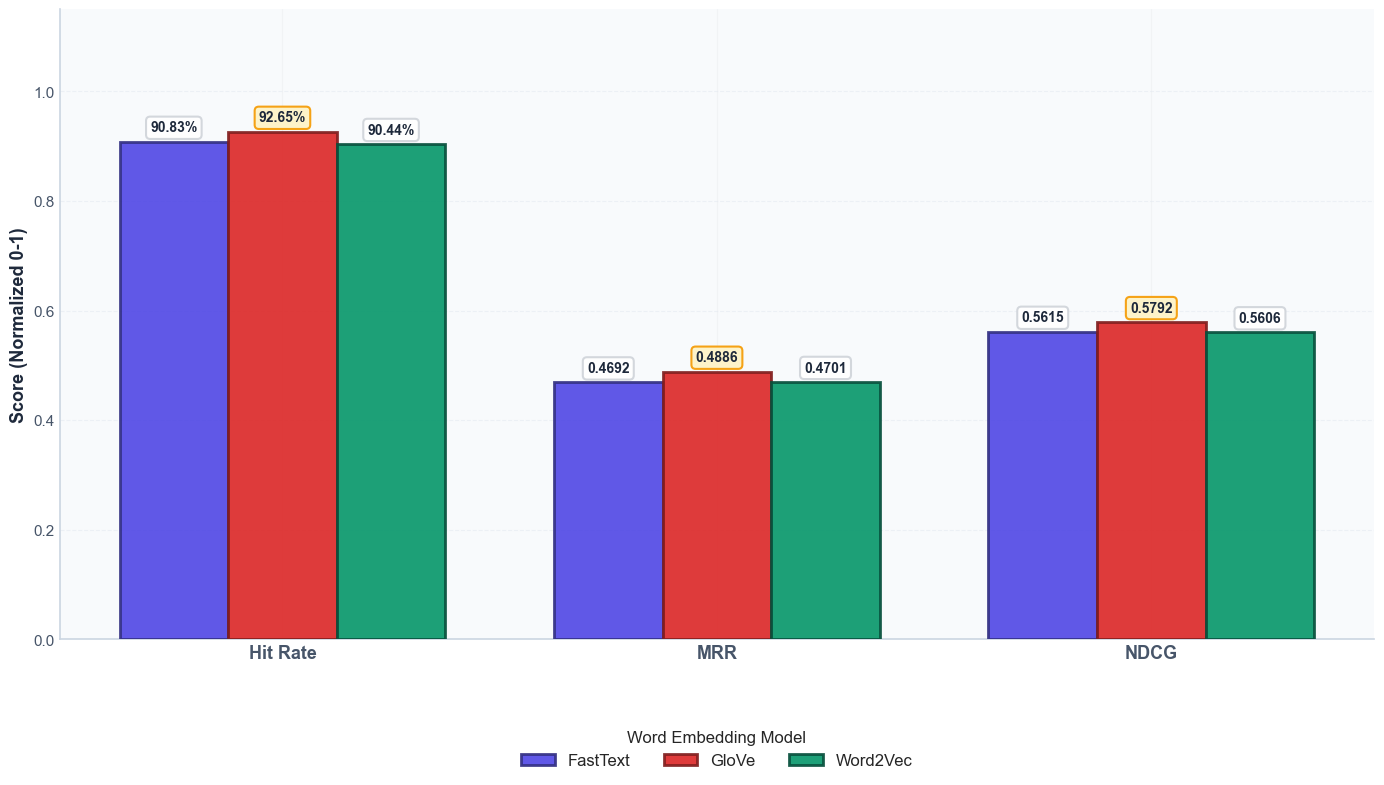

✅ Gambar disimpan: visualisasi/01_bar_chart_perbandingan.png

📊 VISUALISASI 2: Grouped Bar Chart - Semua Metrik


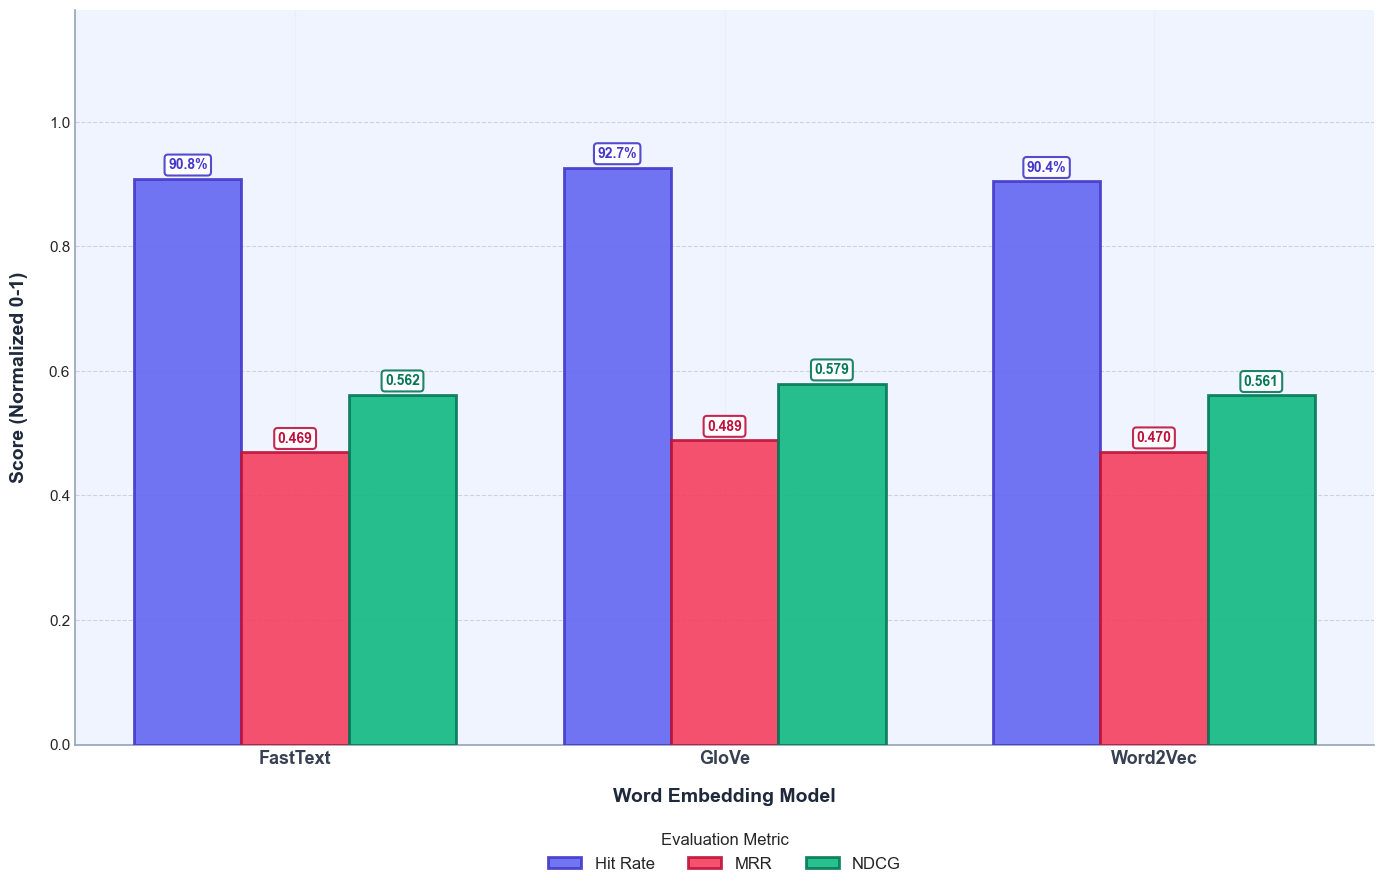

✅ Gambar disimpan: visualisasi/02_grouped_bar_chart.png

📊 VISUALISASI 3: Radar Chart - Profil Performa Model


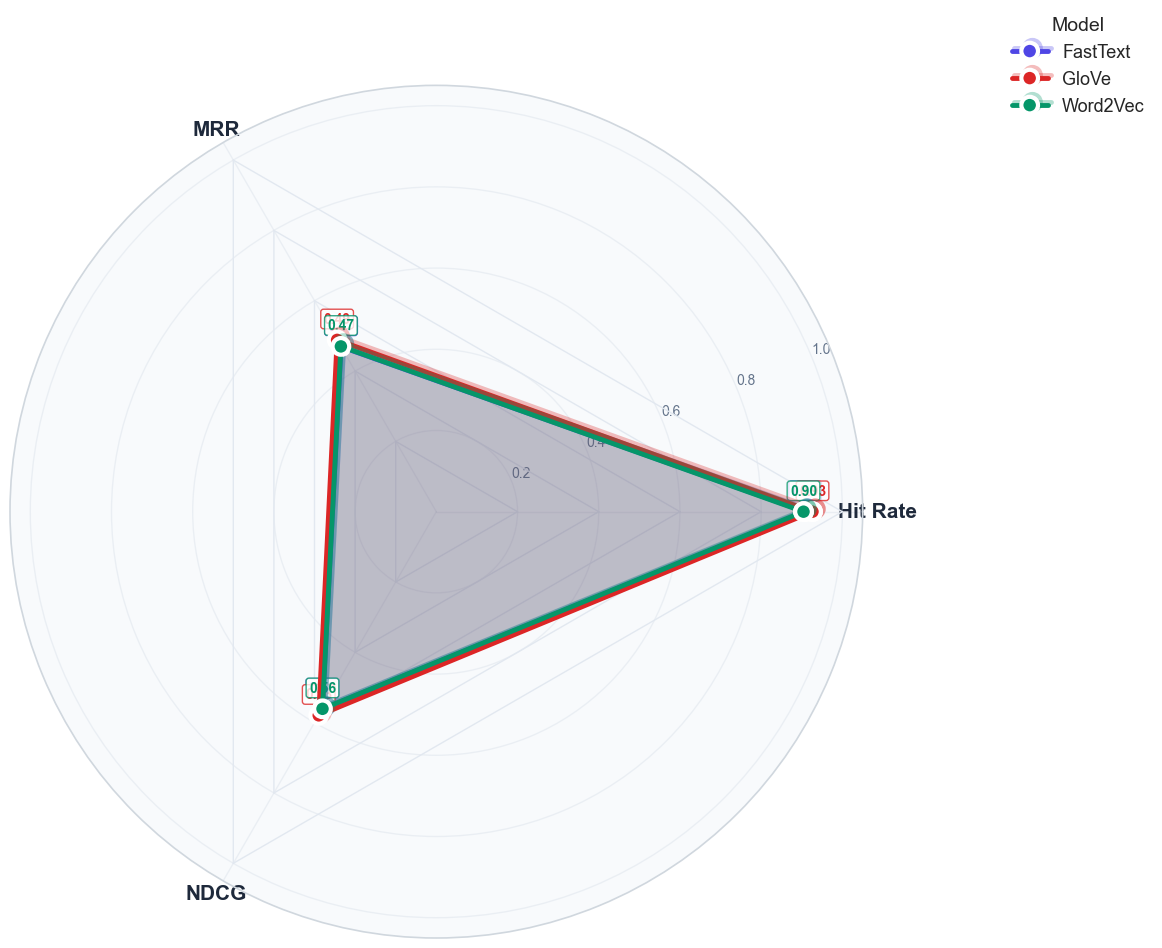

✅ Gambar disimpan: visualisasi/03_radar_chart.png

📊 VISUALISASI 4: Heatmap Perbandingan Performa


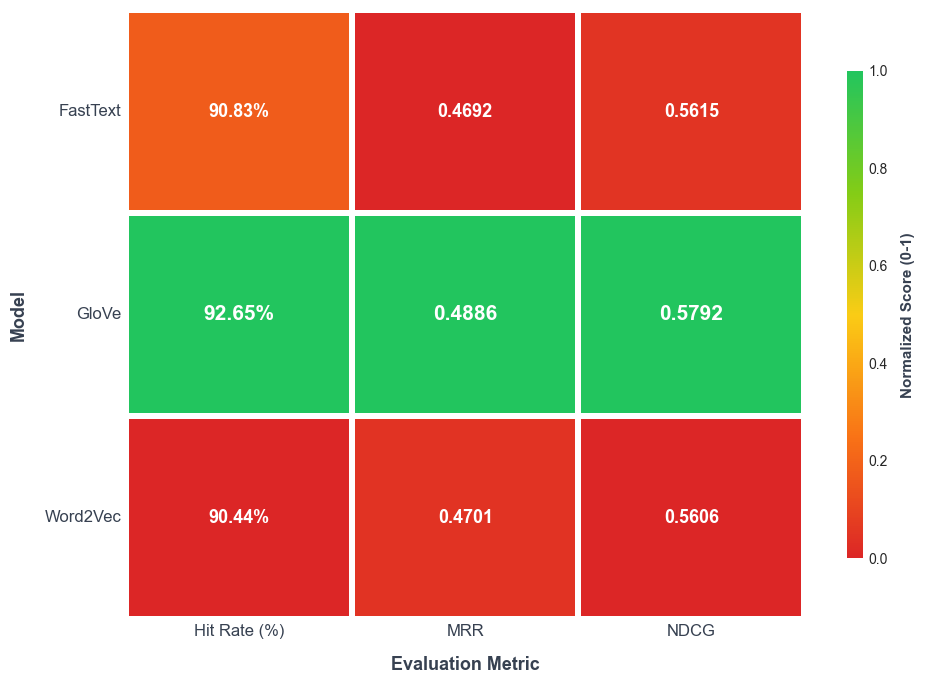

✅ Gambar disimpan: visualisasi/04_heatmap_perbandingan.png

📊 VISUALISASI 5: Horizontal Bar Chart - Ranking Model


C:\Users\Faiq Misbah Yazdi\AppData\Local\Temp\ipykernel_11296\385754778.py:533: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
C:\Users\Faiq Misbah Yazdi\AppData\Local\Temp\ipykernel_11296\385754778.py:534: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(f'{BASE_PATH}/visualisasi/05_horizontal_bar_ranking.png', dpi=300, bbox_inches='tight',
c:\Users\Faiq Misbah Yazdi\Downloads\Paper\Codingan\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


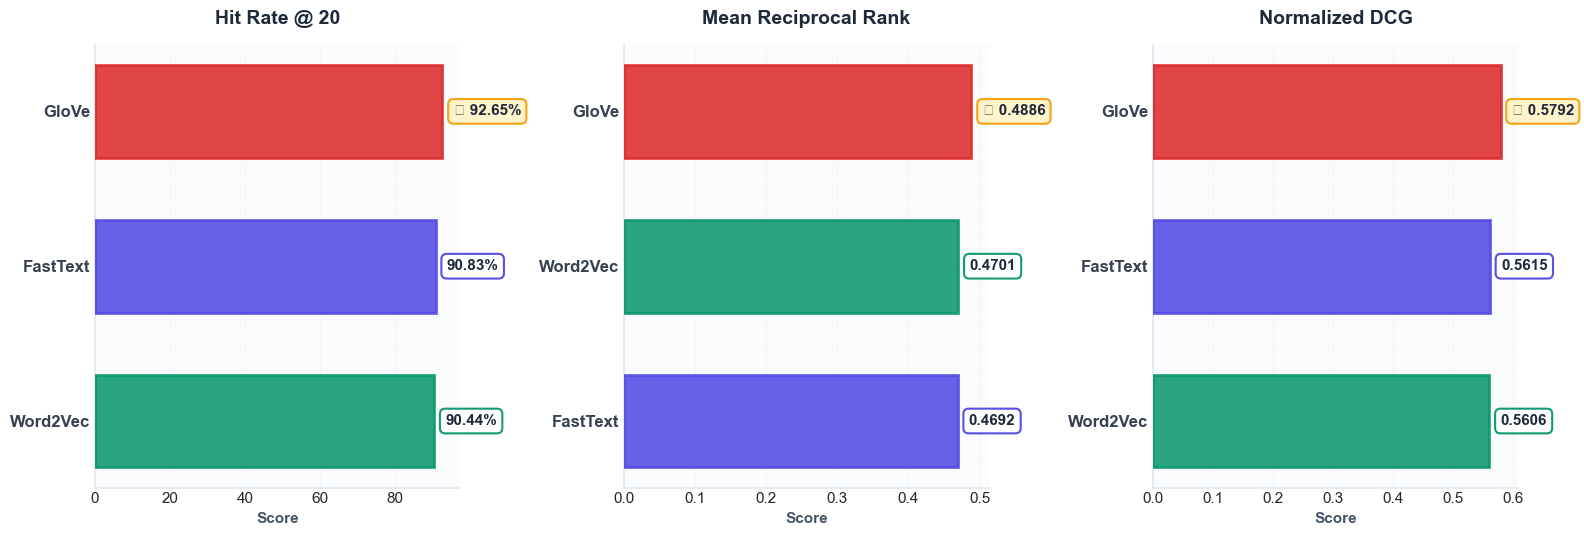

✅ Gambar disimpan: visualisasi/05_horizontal_bar_ranking.png

📊 VISUALISASI 6: Tabel Ringkasan dengan Ranking

📋 Tabel Ranking Model:


Model,Hit Rate,MRR,NDCG,Rank HR,Rank MRR,Rank NDCG,Final
FastText,90.83%,0.4692,0.5615,2,3,2,🥈 2
GloVe,92.65%,0.4886,0.5792,1,1,1,🥇 1
Word2Vec,90.44%,0.4701,0.5606,3,2,3,🥉 3



VISUALIZATION 7: Per-Fold Cross-Validation Stability


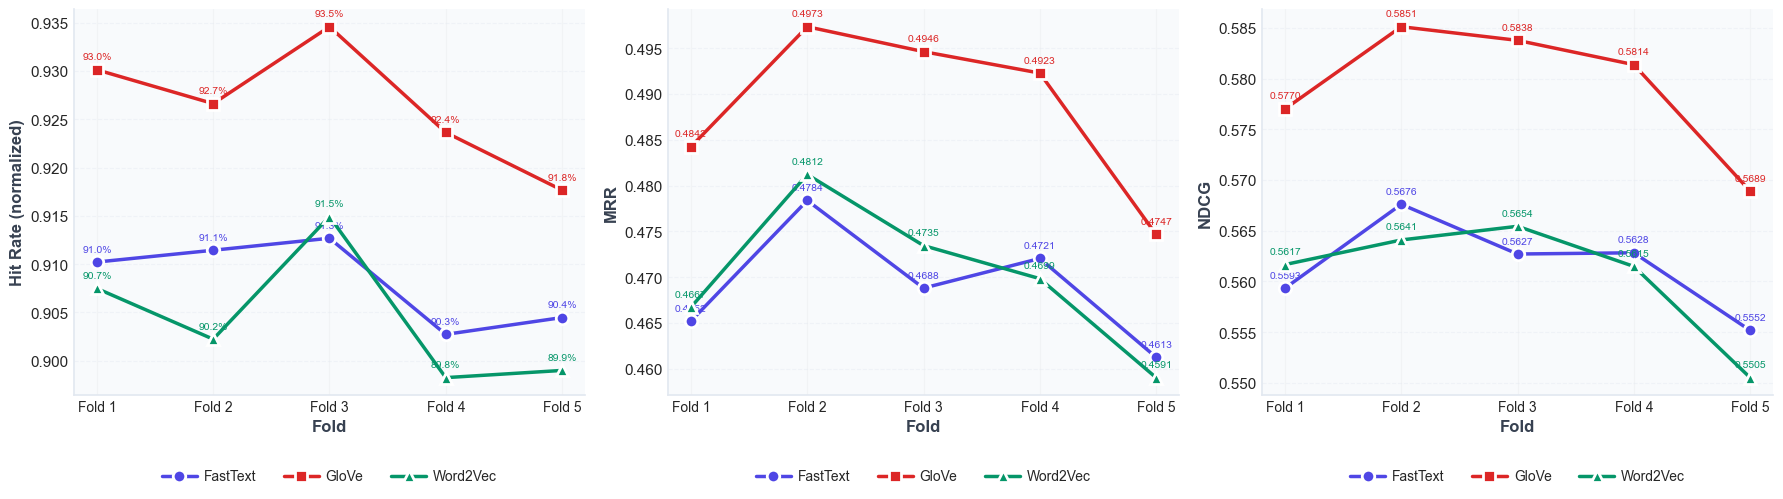

Saved: visualisasi/07_per_fold_comparison.png

🏆 KESIMPULAN ANALISIS PERBANDINGAN MODEL



✅ REKOMENDASI: Gunakan model GloVe untuk sistem rekomendasi musik
   karena memiliki performa terbaik secara keseluruhan.

📁 Semua visualisasi telah disimpan di folder: visualisasi/
   Anda dapat menggunakan gambar-gambar ini untuk Bab 4 Skripsi/Tesis.


In [28]:
# ==============================================================================
# LANGKAH 13: VISUALISASI LENGKAP PERBANDINGAN MODEL
# ==============================================================================
# Visualisasi komprehensif untuk Bab 4 Skripsi/Tesis
# Meliputi: Bar Chart, Radar Chart, Heatmap, dan Grouped Bar Chart

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as path_effects
import seaborn as sns
import pandas as pd
import numpy as np
from IPython.display import display, HTML

print("=" * 80)
print("📊 LANGKAH 13: VISUALISASI PERBANDINGAN MODEL WORD EMBEDDING")
print("=" * 80)

# 1. Siapkan Data dari hasil evaluasi sebelumnya
if 'final_champions' not in globals() or len(final_champions) == 0:
    print("⚠️ Membuat ulang data dari hasil evaluasi terakhir...")
    final_champions = [
        {'Model': 'FastText', 'Hit Rate': 0.9083, 'MRR': 0.4692, 'NDCG': 0.5615},
        {'Model': 'GloVe', 'Hit Rate': 0.9265, 'MRR': 0.4886, 'NDCG': 0.5792},
        {'Model': 'Word2Vec', 'Hit Rate': 0.9044, 'MRR': 0.4701, 'NDCG': 0.5606}
    ]

# Buat DataFrame dari hasil evaluasi
df_vis = pd.DataFrame(final_champions)

# Konversi Hit Rate ke persentase jika belum
if df_vis['Hit Rate'].max() <= 1:
    df_vis['Hit Rate (%)'] = df_vis['Hit Rate'] * 100
else:
    df_vis['Hit Rate (%)'] = df_vis['Hit Rate']

print("\n📋 Data Hasil Evaluasi 3 Model Word Embedding:")
print("-" * 60)

# Tampilkan tabel data dengan styling cantik
display(HTML("""
<style>
.styled-table {
    border-collapse: collapse;
    margin: 25px 0;
    font-size: 14px;
    font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
    min-width: 500px;
    box-shadow: 0 0 20px rgba(0, 0, 0, 0.15);
    border-radius: 10px;
    overflow: hidden;
}
.styled-table thead tr {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    color: #ffffff;
    text-align: center;
    font-weight: bold;
}
.styled-table th, .styled-table td {
    padding: 15px 20px;
    text-align: center;
}
.styled-table tbody tr {
    border-bottom: 1px solid #dddddd;
    background-color: #1e293b;  /* Dark background default */
    color: white;               /* White text default */
    transition: all 0.3s ease;
}
.styled-table tbody tr:nth-of-type(1) {
    background-color: rgba(0, 0, 0, 0.15);  /* Indigo untuk FastText */
}
.styled-table tbody tr:nth-of-type(2) {
    background-color: rgba(0, 0, 0, 0.15);  /* Red untuk GloVe */
}
.styled-table tbody tr:nth-of-type(3) {
    background-color: rgba(0, 0, 0, 0.15);  /* Emerald untuk Word2Vec */
}
.styled-table tbody tr:last-of-type {
    border-bottom: 3px solid #667eea;
}
.styled-table tbody tr:hover {
    background-color: white !important;  /* White bg on hover */
    color: #1e293b !important;           /* Dark text on hover */
    transform: scale(1.01);
}
.styled-table tbody tr:hover td {
    color: #1e293b !important;           /* Ensure td text also dark */
}
</style>
"""))

data_html = f"""
<table class="styled-table">
    <thead>
        <tr>
            <th>Model</th>
            <th>Hit Rate (%)</th>
            <th>MRR</th>
            <th>NDCG</th>
        </tr>
    </thead>
    <tbody>
"""
for _, row in df_vis.iterrows():
    data_html += f"""
        <tr>
            <td><strong>{row['Model']}</strong></td>
            <td>{row['Hit Rate (%)']:.2f}%</td>
            <td>{row['MRR']:.4f}</td>
            <td>{row['NDCG']:.4f}</td>
        </tr>
    """
data_html += "</tbody></table>"
display(HTML(data_html))

# Set style untuk semua visualisasi - PREMIUM STYLE
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 18,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafbfc',
    'axes.edgecolor': '#d0d7de',
    'axes.linewidth': 1.2,
    'grid.alpha': 0.3,
    'grid.linestyle': '-',
    'grid.color': '#e1e4e8'
})

# Palet warna gradient yang cantik
model_colors = {
    'FastText': '#4f46e5',   # Indigo
    'GloVe': '#dc2626',      # Red
    'Word2Vec': '#059669'    # Emerald
}
model_gradients = {
    'FastText': ['#818cf8', '#4f46e5'],
    'GloVe': ['#f87171', '#dc2626'],
    'Word2Vec': ['#34d399', '#059669']
}
colors = [model_colors.get(m, '#6b7280') for m in df_vis['Model']]

# =========================================================================
# VISUALISASI 1: GROUPED BAR CHART - BARS PER MODEL GROUPED BY METRIC
# =========================================================================
print("\n" + "=" * 80)
print("📊 VISUALISASI 1: Bar Chart Perbandingan Semua Metrik")
print("=" * 80)

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')

# Data setup
metrics_list = ['Hit Rate', 'MRR', 'NDCG']
models_list = df_vis['Model'].tolist()
n_metrics = len(metrics_list)
n_models = len(models_list)

# Normalisasi Hit Rate untuk visualisasi yang adil (semua dalam skala 0-1)
values_matrix = {
    'Hit Rate': df_vis['Hit Rate (%)'].values / 100,  # Normalize to 0-1
    'MRR': df_vis['MRR'].values,
    'NDCG': df_vis['NDCG'].values
}

x = np.arange(n_metrics)  # posisi untuk setiap metrik
width = 0.25  # lebar bar

# Buat grouped bars (per model, dikelompokkan berdasarkan metrik)
for i, model in enumerate(models_list):
    model_values = [values_matrix[m][i] for m in metrics_list]
    color = model_colors[model]
    edge_colors = {'FastText': '#312e81', 'GloVe': '#7f1d1d', 'Word2Vec': '#064e3b'}
    
    bars = ax.bar(x + (i - 1) * width, model_values, width, 
                  label=model, color=color, 
                  edgecolor=edge_colors[model], linewidth=2,
                  alpha=0.9, zorder=3)
    
    # Annotate values
    for j, (bar, metric) in enumerate(zip(bars, metrics_list)):
        height = bar.get_height()
        
        # Format value sesuai metrik
        if metric == 'Hit Rate':
            val_text = f'{height*100:.2f}%'
        else:
            val_text = f'{height:.4f}'
        
        # Check if best value for this metric
        metric_values = [values_matrix[metric][k] for k in range(n_models)]
        is_best = height == max(metric_values)
        
        bbox_color = '#fef3c7' if is_best else 'white'
        border_color = '#f59e0b' if is_best else '#d1d5db'
        
        ax.annotate(val_text,
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   ha='center', va='bottom', fontsize=10, fontweight='bold',
                   color='#1e293b',
                   xytext=(0, 5), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor=bbox_color,
                            edgecolor=border_color, linewidth=1.5, alpha=0.95))

# Styling
ax.set_ylabel('Score (Normalized 0-1)', fontsize=13, fontweight='bold', color='#1e293b')
ax.set_title('', 
             fontsize=16, fontweight='bold', color='#1e293b')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list, fontsize=13, fontweight='bold', color='#374151')
ax.set_ylim([0, 1.15])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cbd5e1')
ax.spines['bottom'].set_color('#cbd5e1')
ax.set_facecolor('#f8fafc')
ax.tick_params(colors='#475569')
ax.grid(axis='y', alpha=0.5, linestyle='--', color='#e2e8f0', zorder=1)

# Legend di bawah tengah
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), 
                   ncol=3, fontsize=12, framealpha=0.95, 
                   edgecolor='#6366f1', fancybox=True, shadow=True,
                   title='Word Embedding Model', title_fontsize=12)
legend.get_frame().set_linewidth(2)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/visualisasi/01_bar_chart_perbandingan.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Gambar disimpan: visualisasi/01_bar_chart_perbandingan.png")

# =========================================================================
# VISUALISASI 2: GROUPED BAR CHART - GLASSMORPHISM STYLE
# =========================================================================
print("\n" + "=" * 80)
print("📊 VISUALISASI 2: Grouped Bar Chart - Semua Metrik")
print("=" * 80)

df_normalized = df_vis.copy()
df_normalized['Hit Rate Norm'] = df_vis['Hit Rate (%)'] / 100

fig, ax = plt.subplots(figsize=(14, 9))
fig.patch.set_facecolor('white')

# Background gradient effect
ax.set_facecolor('#f0f4ff')

x = np.arange(len(df_vis['Model']))
width = 0.25

# Warna metrik yang cantik
metric_colors_list = ['#6366f1', '#f43f5e', '#10b981']
metric_names = ['Hit Rate', 'MRR', 'NDCG']

bars1 = ax.bar(x - width, df_normalized['Hit Rate Norm'], width, label='Hit Rate', 
               color=metric_colors_list[0], edgecolor='#4338ca', linewidth=2, alpha=0.9, zorder=3)
bars2 = ax.bar(x, df_vis['MRR'], width, label='MRR', 
               color=metric_colors_list[1], edgecolor='#be123c', linewidth=2, alpha=0.9, zorder=3)
bars3 = ax.bar(x + width, df_vis['NDCG'], width, label='NDCG', 
               color=metric_colors_list[2], edgecolor='#047857', linewidth=2, alpha=0.9, zorder=3)

ax.set_xlabel('Word Embedding Model', fontsize=14, fontweight='bold', color='#1e293b', labelpad=15)
ax.set_ylabel('Score (Normalized 0-1)', fontsize=14, fontweight='bold', color='#1e293b', labelpad=15)
ax.set_title('', 
             fontsize=18, fontweight='bold', color='#1e293b')
ax.set_xticks(x)
ax.set_xticklabels(df_vis['Model'], fontsize=13, fontweight='bold', color='#374151')
ax.set_ylim([0, 1.18])

# Legend di bawah tengah
legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), 
                   ncol=3, fontsize=12, framealpha=0.95, edgecolor='#6366f1',
                   fancybox=True, shadow=True, title='Evaluation Metric', title_fontsize=12)
legend.get_frame().set_linewidth(2)

# Grid styling
ax.grid(axis='y', alpha=0.4, linestyle='--', color='#94a3b8', zorder=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#94a3b8')
ax.spines['bottom'].set_color('#94a3b8')

# Annotate dengan styling premium
for bars, values, fmt, color in [
    (bars1, df_vis['Hit Rate (%)'], '{:.1f}%', '#4338ca'),
    (bars2, df_vis['MRR'], '{:.3f}', '#be123c'),
    (bars3, df_vis['NDCG'], '{:.3f}', '#047857')
]:
    for bar, val in zip(bars, values):
        ax.annotate(fmt.format(val),
                   xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                   ha='center', va='bottom', fontsize=10, fontweight='bold', color=color,
                   xytext=(0, 5), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.25', facecolor='white', 
                            edgecolor=color, alpha=0.9, linewidth=1.5))

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/visualisasi/02_grouped_bar_chart.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Gambar disimpan: visualisasi/02_grouped_bar_chart.png")

# =========================================================================
# VISUALISASI 3: RADAR CHART - NEON GLOW EFFECT
# =========================================================================
print("\n" + "=" * 80)
print("📊 VISUALISASI 3: Radar Chart - Profil Performa Model")
print("=" * 80)

categories = ['Hit Rate', 'MRR', 'NDCG']
n_cats = len(categories)

df_radar = pd.DataFrame()
df_radar['Model'] = df_vis['Model']
df_radar['Hit Rate'] = df_vis['Hit Rate (%)'] / 100
df_radar['MRR'] = df_vis['MRR']
df_radar['NDCG'] = df_vis['NDCG']

angles = [n / float(n_cats) * 2 * np.pi for n in range(n_cats)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('white')

# Background styling
ax.set_facecolor('#f8fafc')

# Tambahkan ring background
for ring in [0.2, 0.4, 0.6, 0.8, 1.0]:
    ax.plot(angles, [ring]*4, color='#e2e8f0', linewidth=1, linestyle='-', zorder=1)

for idx, row in df_radar.iterrows():
    values = [row['Hit Rate'], row['MRR'], row['NDCG']]
    values += values[:1]
    
    model_name = row['Model']
    color = model_colors.get(model_name, '#6b7280')
    
    # Line dengan glow effect
    ax.plot(angles, values, 'o-', linewidth=3.5, label=model_name, color=color, 
            markersize=12, markeredgecolor='white', markeredgewidth=3, zorder=4,
            path_effects=[path_effects.SimpleLineShadow(offset=(2,2), shadow_color=color, alpha=0.3),
                         path_effects.Normal()])
    
    # Fill dengan transparency
    ax.fill(angles, values, alpha=0.15, color=color, zorder=2)
    
    # Annotate nilai di setiap titik
    for angle, value, cat in zip(angles[:-1], values[:-1], categories):
        ax.annotate(f'{value:.2f}', xy=(angle, value), ha='center', va='bottom',
                   fontsize=10, fontweight='bold', color=color,
                   xytext=(0, 10), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', 
                            edgecolor=color, alpha=0.8))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=15, fontweight='bold', color='#1e293b')
ax.set_ylim([0, 1.05])
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=10, color='#64748b')

# Legend premium
legend = ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=13, 
                   framealpha=0.95, edgecolor='#6366f1', fancybox=True, shadow=True,
                   title='Model', title_fontsize=14)
legend.get_frame().set_linewidth(2)

ax.set_title('', 
             fontsize=18, fontweight='bold', color='#1e293b', pad=30)

# Grid styling
ax.yaxis.grid(True, color='#cbd5e1', linestyle='-', linewidth=1)
ax.xaxis.grid(True, color='#cbd5e1', linestyle='-', linewidth=1)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/visualisasi/03_radar_chart.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Gambar disimpan: visualisasi/03_radar_chart.png")

# =========================================================================
# VISUALISASI 4: HEATMAP - IMPROVED DESIGN
# =========================================================================
print("\n" + "=" * 80)
print("📊 VISUALISASI 4: Heatmap Perbandingan Performa")
print("=" * 80)

heatmap_data = df_vis[['Model', 'Hit Rate (%)', 'MRR', 'NDCG']].copy()
heatmap_data = heatmap_data.set_index('Model')
heatmap_data.columns = ['Hit Rate (%)', 'MRR', 'NDCG']

# Normalisasi untuk visualisasi
heatmap_norm = heatmap_data.copy()
for col in heatmap_norm.columns:
    col_min = heatmap_norm[col].min()
    col_max = heatmap_norm[col].max()
    if col_max != col_min:
        heatmap_norm[col] = (heatmap_norm[col] - col_min) / (col_max - col_min)
    else:
        heatmap_norm[col] = 1.0

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

# Custom colormap - gradient hijau ke merah yang lebih cantik
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('custom_rg', 
    ['#dc2626', '#f97316', '#facc15', '#84cc16', '#22c55e'], N=256)

# Heatmap
hm = sns.heatmap(heatmap_norm, annot=False, cmap=custom_cmap, 
                 linewidths=4, linecolor='white', 
                 cbar_kws={'label': 'Normalized Score (0-1)', 'shrink': 0.8, 'aspect': 30},
                 ax=ax, vmin=0, vmax=1)

# Custom annotation dengan nilai asli dan styling
for i, model in enumerate(heatmap_data.index):
    for j, col in enumerate(heatmap_data.columns):
        val = heatmap_data.loc[model, col]
        norm_val = heatmap_norm.loc[model, col]
        
        # Warna text berdasarkan background
        text_color = 'white' if norm_val < 0.4 or norm_val > 0.7 else '#1e293b'
        
        if col == 'Hit Rate (%)':
            text = f'{val:.2f}%'
        else:
            text = f'{val:.4f}'
        
        # Cek nilai terbaik
        is_best = val == heatmap_data[col].max()
        
        # Font styling untuk nilai terbaik
        fontweight = 'bold'
        fontsize = 15 if is_best else 13
        
        # Tambahkan star untuk nilai terbaik
        if is_best:
            text = f'{text}'
        
        ax.text(j + 0.5, i + 0.5, text, ha='center', va='center', 
               fontsize=fontsize, fontweight=fontweight, color=text_color)

ax.set_title('', 
             fontsize=16, fontweight='bold', color='#1e293b', pad=15)
ax.set_xlabel('Evaluation Metric', fontsize=13, fontweight='bold', color='#374151', labelpad=12)
ax.set_ylabel('Model', fontsize=13, fontweight='bold', color='#374151', labelpad=12)
ax.tick_params(axis='both', labelsize=12, colors='#374151')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

# Colorbar styling
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_ylabel('Normalized Score (0-1)', fontsize=11, fontweight='bold', color='#374151', labelpad=10)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/visualisasi/04_heatmap_perbandingan.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Gambar disimpan: visualisasi/04_heatmap_perbandingan.png")

# =========================================================================
# VISUALISASI 5: HORIZONTAL BAR CHART - CLEANER DESIGN
# =========================================================================
print("\n" + "=" * 80)
print("📊 VISUALISASI 5: Horizontal Bar Chart - Ranking Model")
print("=" * 80)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.suptitle('', fontsize=18, fontweight='bold', 
             color='#1e293b', y=1.02)

metrics = [('Hit Rate (%)', 'Hit Rate @ 20'), 
           ('MRR', 'Mean Reciprocal Rank'), 
           ('NDCG', 'Normalized DCG')]

for ax, (metric, title) in zip(axes, metrics):
    df_sorted = df_vis.sort_values(metric, ascending=True)
    colors_sorted = [model_colors.get(m, '#6b7280') for m in df_sorted['Model']]
    y_pos = np.arange(len(df_sorted))
    
    # Simple horizontal bar
    bars = ax.barh(y_pos, df_sorted[metric], color=colors_sorted, 
                   edgecolor=[c for c in colors_sorted], linewidth=2,
                   height=0.6, alpha=0.85, zorder=3)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df_sorted['Model'], fontsize=12, fontweight='bold', color='#374151')
    ax.set_title(title, fontsize=14, fontweight='bold', color='#1e293b', pad=15)
    ax.set_xlabel('Score', fontsize=11, fontweight='bold', color='#475569')
    
    # Styling
    ax.set_facecolor('#fafbfc')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#e2e8f0')
    ax.spines['bottom'].set_color('#e2e8f0')
    ax.grid(axis='x', alpha=0.4, linestyle='--', color='#e2e8f0', zorder=1)
    
    # Label nilai
    for i, (bar, val, color) in enumerate(zip(bars, df_sorted[metric], colors_sorted)):
        is_best = val == df_sorted[metric].max()
        fmt = '{:.2f}%' if '%' in metric else '{:.4f}'
        
        # Badge styling
        bbox_color = '#fef3c7' if is_best else 'white'
        border_color = '#f59e0b' if is_best else color
        
        text = fmt.format(val)
        if is_best:
            text = f'★ {text}'
        
        ax.annotate(text,
                   xy=(bar.get_width(), bar.get_y() + bar.get_height()/2),
                   ha='left', va='center', fontsize=11, fontweight='bold', color='#1e293b',
                   xytext=(8, 0), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.35', facecolor=bbox_color, 
                            edgecolor=border_color, linewidth=1.5, alpha=0.95))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f'{BASE_PATH}/visualisasi/05_horizontal_bar_ranking.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("✅ Gambar disimpan: visualisasi/05_horizontal_bar_ranking.png")

# =========================================================================
# VISUALISASI 6: SUMMARY TABLE DENGAN RANKING - FIXED TEXT COLOR
# =========================================================================
print("\n" + "=" * 80)
print("📊 VISUALISASI 6: Tabel Ringkasan dengan Ranking")
print("=" * 80)

# Hitung ranking untuk setiap metrik
df_ranking = df_vis[['Model', 'Hit Rate (%)', 'MRR', 'NDCG']].copy()
df_ranking['Rank HR'] = df_ranking['Hit Rate (%)'].rank(ascending=False).astype(int)
df_ranking['Rank MRR'] = df_ranking['MRR'].rank(ascending=False).astype(int)
df_ranking['Rank NDCG'] = df_ranking['NDCG'].rank(ascending=False).astype(int)
df_ranking['Total'] = df_ranking['Rank HR'] + df_ranking['Rank MRR'] + df_ranking['Rank NDCG']
df_ranking['Final'] = df_ranking['Total'].rank().astype(int)

print("\n📋 Tabel Ranking Model:")

# Premium styled table dengan HTML - FIXED TEXT COLORS
ranking_html = """
<style>
.ranking-table {
    border-collapse: collapse;
    margin: 25px 0;
    font-size: 13px;
    font-family: 'Segoe UI', sans-serif;
    box-shadow: 0 4px 20px rgba(0, 0, 0, 0.15);
    border-radius: 12px;
    overflow: hidden;
    width: 100%;
}
.ranking-table thead tr {
    background: linear-gradient(135deg, #4f46e5 0%, #7c3aed 100%);
    color: white;
    text-align: center;
    font-weight: bold;
}
.ranking-table th {
    padding: 15px 12px;
    font-size: 12px;
}
.ranking-table td {
    padding: 14px 12px;
    text-align: center;
    border-bottom: 1px solid #e5e7eb;
    color: white;
}
.ranking-table tbody tr:hover {
    background-color: white !important;
}
.ranking-table tbody tr:hover td {
    color: #1e293b !important;  /* Teks hitam saat hover */
}
.rank-1 { background-color: rgba(0, 0, 0, 0.15); }
.rank-1 td { color: white; font-weight: bold; }
.rank-2 { background-color: rgba(0, 0, 0, 0.15); }
.rank-2 td { color: white; }
.rank-3 { background-color: rgba(0, 0, 0, 0.15); }
.rank-3 td { color: white; }
.medal { font-size: 18px; }
</style>
<table class="ranking-table">
    <thead>
        <tr>
            <th>Model</th>
            <th>Hit Rate</th>
            <th>MRR</th>
            <th>NDCG</th>
            <th>Rank HR</th>
            <th>Rank MRR</th>
            <th>Rank NDCG</th>
            <th>Final</th>
        </tr>
    </thead>
    <tbody>
"""

medals = {1: '🥇', 2: '🥈', 3: '🥉'}
for _, row in df_ranking.iterrows():
    rank_class = f"rank-{int(row['Final'])}"
    medal = medals.get(int(row['Final']), '')
    ranking_html += f"""
        <tr class="{rank_class}">
            <td><strong>{row['Model']}</strong></td>
            <td>{row['Hit Rate (%)']:.2f}%</td>
            <td>{row['MRR']:.4f}</td>
            <td>{row['NDCG']:.4f}</td>
            <td>{int(row['Rank HR'])}</td>
            <td>{int(row['Rank MRR'])}</td>
            <td>{int(row['Rank NDCG'])}</td>
            <td><span class="medal">{medal}</span> {int(row['Final'])}</td>
        </tr>
    """
ranking_html += "</tbody></table>"
display(HTML(ranking_html))

# =========================================================================

# VISUALIZATION 7: Per-Fold Stability — All Models Comparison
# =========================================================================
print("\n" + "=" * 80)
print("VISUALIZATION 7: Per-Fold Cross-Validation Stability")
print("=" * 80)

import os
os.makedirs(f'{BASE_PATH}/visualisasi', exist_ok=True)

_mc7      = {'FastText': '#4f46e5', 'GloVe': '#dc2626', 'Word2Vec': '#059669'}
_marker7  = {'FastText': 'o',       'GloVe': 's',       'Word2Vec': '^'}
_res_map  = {'FastText': 'res_ft',  'GloVe': 'res_glove', 'Word2Vec': 'res_w2v'}
_mfd      = {}

for _mname, _rv in _res_map.items():
    try:
        _res = globals()[_rv]
        _rows = [r for r in _res['Fold Results'] if str(r['Fold']).startswith('Fold')]
        _mfd[_mname] = {
            'Hit Rate': [r['Hit Rate (%)'] / 100 for r in _rows],
            'MRR':      [float(r['MRR'])          for r in _rows],
            'NDCG':     [float(r['NDCG'])          for r in _rows],
        }
    except Exception as _e:
        print(f"  Warning: {_mname} fold data not found ({_e})")

_fold_x7   = list(range(1, 6))
_fold_lbl7 = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
_metrics7  = ['Hit Rate', 'MRR', 'NDCG']
_ylabels7  = ['Hit Rate (normalized)', 'MRR', 'NDCG']

fig7, axes7 = plt.subplots(1, 3, figsize=(18, 6))
fig7.patch.set_facecolor('white')

for _ax7, _m7, _yl7 in zip(axes7, _metrics7, _ylabels7):
    _ax7.set_facecolor('#f8fafc')
    for _mname, _data in _mfd.items():
        _ax7.plot(_fold_x7, _data[_m7],
                  marker=_marker7[_mname], linestyle='-', linewidth=2.5, markersize=9,
                  label=_mname, color=_mc7[_mname],
                  markeredgecolor='white', markeredgewidth=2, zorder=3)
        for _xi7, _yi7 in zip(_fold_x7, _data[_m7]):
            _lbl7 = f'{_yi7*100:.1f}%' if _m7 == 'Hit Rate' else f'{_yi7:.4f}'
            _ax7.annotate(_lbl7, xy=(_xi7, _yi7), ha='center', va='bottom',
                          fontsize=7.5, color=_mc7[_mname],
                          xytext=(0, 6), textcoords='offset points')
    _ax7.set_xlabel('Fold', fontsize=12, fontweight='bold', color='#374151')
    _ax7.set_ylabel(_yl7, fontsize=12, fontweight='bold', color='#374151')
    _ax7.set_xticks(_fold_x7)
    _ax7.set_xticklabels(_fold_lbl7, fontsize=10)
    _ax7.spines['top'].set_visible(False)
    _ax7.spines['right'].set_visible(False)
    _ax7.spines['left'].set_color('#e2e8f0')
    _ax7.spines['bottom'].set_color('#e2e8f0')
    _ax7.grid(axis='y', alpha=0.4, linestyle='--', color='#e2e8f0', zorder=1)
    _ax7.legend(loc='upper center', bbox_to_anchor=(0.5, -0.16),
               ncol=3, fontsize=10, framealpha=0.95,
               edgecolor='#d1d5db', fancybox=True,
               handlelength=2.5, handletextpad=0.5)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(f'{BASE_PATH}/visualisasi/07_per_fold_comparison.png',
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print("Saved: visualisasi/07_per_fold_comparison.png")
del fig7, axes7, _mfd, _mc7, _marker7, _res_map

# KESIMPULAN - PREMIUM CARD STYLE
# =========================================================================
print("\n" + "=" * 80)
print("🏆 KESIMPULAN ANALISIS PERBANDINGAN MODEL")
print("=" * 80)

best_overall = df_ranking.loc[df_ranking['Final'].idxmin()]
best_hitrate = df_vis.loc[df_vis['Hit Rate (%)'].idxmax()]
best_mrr = df_vis.loc[df_vis['MRR'].idxmax()]
best_ndcg = df_vis.loc[df_vis['NDCG'].idxmax()]

# Summary card dengan HTML premium - FIXED TEXT COLORS
summary_html = f"""
<style>
.summary-container {{
    font-family: 'Segoe UI', sans-serif;
    max-width: 800px;
    margin: 20px 0;
}}
.summary-card {{
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    border-radius: 16px;
    padding: 25px 30px;
    color: white;
    box-shadow: 0 10px 40px rgba(102, 126, 234, 0.4);
    margin-bottom: 20px;
}}
.summary-card h2 {{
    margin: 0 0 20px 0;
    font-size: 20px;
    display: flex;
    align-items: center;
    gap: 10px;
    color: white;
}}
.metric-row {{
    display: flex;
    justify-content: space-between;
    padding: 12px 0;
    border-bottom: 1px solid rgba(255,255,255,0.2);
}}
.metric-row:last-child {{
    border-bottom: none;
}}
.metric-label {{
    font-size: 14px;
    opacity: 0.9;
    color: white;
}}
.metric-value {{
    font-size: 16px;
    font-weight: bold;
    color: white;
}}
.winner-card {{
    background: linear-gradient(135deg, #10b981 0%, #059669 100%);
    border-radius: 16px;
    padding: 25px 30px;
    color: white;
    box-shadow: 0 10px 40px rgba(16, 185, 129, 0.4);
    text-align: center;
}}
.winner-card h2 {{
    margin: 0 0 10px 0;
    font-size: 24px;
    color: white;
}}
.winner-model {{
    font-size: 32px;
    font-weight: bold;
    margin: 15px 0;
    color: white;
}}
.winner-note {{
    font-size: 13px;
    opacity: 0.9;
    color: white;
}}
.interp-card {{
    background: white;
    border-radius: 12px;
    padding: 20px 25px;
    margin-top: 20px;
    box-shadow: 0 4px 15px rgba(0,0,0,0.1);
    border-left: 4px solid #6366f1;
}}
.interp-title {{
    font-size: 16px;
    font-weight: bold;
    color: #1e293b;
    margin-bottom: 15px;
}}
.interp-item {{
    padding: 10px 0;
    border-bottom: 1px solid #f1f5f9;
    color: #1e293b;
    font-size: 13px;
    line-height: 1.6;
}}
.interp-item:last-child {{
    border-bottom: none;
}}
.model-name {{
    font-weight: bold;
    color: #4f46e5;
}}
</style>

<div class="summary-container">
    <div class="summary-card">
        <h2>Hasil Evaluasi 3 Model Word Embedding</h2>
        <div class="metric-row">
            <span class="metric-label">Hit Rate @ 20</span>
            <span class="metric-value">{best_hitrate['Model']} → {best_hitrate['Hit Rate (%)']:.2f}%</span>
        </div>
        <div class="metric-row">
            <span class="metric-label">Mean Reciprocal Rank (MRR)</span>
            <span class="metric-value">{best_mrr['Model']} → {best_mrr['MRR']:.4f}</span>
        </div>
        <div class="metric-row">
            <span class="metric-label">Normalized DCG (NDCG)</span>
            <span class="metric-value">{best_ndcg['Model']} → {best_ndcg['NDCG']:.4f}</span>
        </div>
    </div>
    
    <div class="winner-card">
        <h2>Model Terbaik Keseluruhan</h2>
        <div class="winner-model">{best_overall['Model']}</div>
        <div class="winner-note">Berdasarkan agregasi ranking dari semua metrik evaluasi</div>
    </div>
    
    <div class="interp-card">
        <div class="interp-title">Interpretasi Hasil</div>
"""

for _, row in df_vis.iterrows():
    model = row['Model']
    hr = row['Hit Rate (%)']
    mrr = row['MRR']
    ndcg = row['NDCG']
    
    summary_html += f"""
        <div class="interp-item">
            <span class="model-name">{model}:</span><br>
            • Hit Rate {hr:.2f}% → {hr:.0f} dari 100 query mendapat minimal 1 lagu relevan di Top-20<br>
            • MRR {mrr:.4f} → Lagu relevan pertama muncul rata-rata di posisi ke-{1/mrr:.1f}<br>
            • NDCG {ndcg:.4f} → Kualitas ranking {'baik' if ndcg > 0.5 else 'cukup'}
        </div>
    """

summary_html += """
    </div>
</div>
"""

display(HTML(summary_html))

# Rekomendasi final
print("\n" + "=" * 80)
print(f"✅ REKOMENDASI: Gunakan model {best_overall['Model']} untuk sistem rekomendasi musik")
print("   karena memiliki performa terbaik secara keseluruhan.")
print("=" * 80)

print("\n📁 Semua visualisasi telah disimpan di folder: visualisasi/")
print("   Anda dapat menggunakan gambar-gambar ini untuk Bab 4 Skripsi/Tesis.")

# =========================================================================

# ***UI GRADIO***

In [41]:
# ==============================================================================
# LANGKAH 14: USER INTERFACE (UI) - SISTEM REKOMENDASI MUSIK
# ==============================================================================
# Sistem Rekomendasi dengan pilihan model:
# - GloVe (Best: 92.65% Hit Rate)
# - FastText (90.83% Hit Rate)
# - Word2Vec (90.44% Hit Rate)

import os
import numpy as np
import pandas as pd
import faiss
import io
from sklearn.feature_extraction.text import TfidfVectorizer
import re

print("=" * 80)
print("🎵 LANGKAH 14: SISTEM REKOMENDASI MUSIK BERBASIS USER HISTORY")
print("=" * 80)

# 1. Install dan import Gradio
try:
    import gradio as gr
    print("✅ Gradio sudah terinstall")
except ImportError:
    print("📦 Menginstall Gradio...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'gradio', '-q'])
    import gradio as gr
    print("✅ Gradio berhasil diinstall")

# 2. Load semua embeddings yang tersedia
print("\n📂 Loading semua embeddings...")

# Dictionary untuk menyimpan embeddings dan FAISS index untuk setiap model
model_data = {}
model_hitrates = {
    'GloVe': 92.65,
    'FastText': 90.83,
    'Word2Vec': 90.44
}

# Load GloVe embeddings
glove_path = f"{BASE_PATH}/embeddings/glove_embeddings_tfidf.npy"
if os.path.exists(glove_path):
    with open(glove_path, 'rb') as _np_f: _np_data = _np_f.read()
    glove_emb = np.load(io.BytesIO(_np_data))
    model_data['GloVe'] = {'embeddings': glove_emb, 'index': None}
    print(f"✅ GloVe Embeddings loaded: {glove_emb.shape}")
else:
    print(f"⚠️ GloVe embeddings not found at {glove_path}")

# Load FastText embeddings
fasttext_path = f"{BASE_PATH}/embeddings/fasttext_embeddings_tfidf.npy"
if os.path.exists(fasttext_path):
    with open(fasttext_path, 'rb') as _np_f: _np_data = _np_f.read()
    fasttext_emb = np.load(io.BytesIO(_np_data))
    model_data['FastText'] = {'embeddings': fasttext_emb, 'index': None}
    print(f"✅ FastText Embeddings loaded: {fasttext_emb.shape}")
else:
    print(f"⚠️ FastText embeddings not found at {fasttext_path}")

# Load Word2Vec embeddings
w2v_path = f"{BASE_PATH}/embeddings/word2vec_embeddings_tfidf.npy"
if os.path.exists(w2v_path):
    with open(w2v_path, 'rb') as _np_f: _np_data = _np_f.read()
    w2v_emb = np.load(io.BytesIO(_np_data))
    model_data['Word2Vec'] = {'embeddings': w2v_emb, 'index': None}
    print(f"✅ Word2Vec Embeddings loaded: {w2v_emb.shape}")
else:
    print(f"⚠️ Word2Vec embeddings not found at {w2v_path}")

# 3. Tentukan jumlah lagu valid (dari embeddings)
n_songs_valid = list(model_data.values())[0]['embeddings'].shape[0]
print(f"\n📊 Jumlah lagu dengan embeddings: {n_songs_valid}")

# 4. Build FAISS index untuk setiap model
print("\n🔧 Building FAISS indexes...")
for model_name, data in model_data.items():
    emb = data['embeddings']
    embedding_dim = emb.shape[1]
    
    # Create FAISS index
    index = faiss.IndexFlatIP(embedding_dim)
    
    # Normalize embeddings untuk cosine similarity
    emb_norm = emb.copy()
    faiss.normalize_L2(emb_norm)
    index.add(emb_norm.astype('float32'))
    
    model_data[model_name]['embeddings_norm'] = emb_norm
    model_data[model_name]['index'] = index
    print(f"   ✅ {model_name} FAISS index: {index.ntotal} vectors")

# 5. REGENERATE User Profile dengan index yang VALID (berdasarkan n_songs_valid)
# Termasuk play_count (jumlah kali mendengarkan) untuk setiap lagu
print("\n👤 Regenerating User Profiles dengan index valid...")
np.random.seed(42)

list_user_profiles = []
n_users_to_generate = 100

for i in range(n_users_to_generate):
    # Setiap user menyukai 5-15 lagu dengan index VALID (0 sampai n_songs_valid-1)
    n_liked = np.random.randint(5, 15)
    liked_songs = np.random.choice(n_songs_valid, size=n_liked, replace=False)
    
    # Generate play count untuk setiap lagu (5 - 150 kali, distribusi eksponensial)
    # Lagu pertama biasanya paling sering didengar
    play_counts = np.random.exponential(scale=30, size=n_liked).astype(int) + 5
    play_counts = np.clip(play_counts, 5, 150)  # Limit antara 5-150
    play_counts = sorted(play_counts.tolist(), reverse=True)  # Sort descending, convert to list
    
    list_user_profiles.append({
        'user_id': i,
        'liked_song_indices': liked_songs.tolist(),
        'play_counts': play_counts  # Sudah list, tidak perlu .tolist()
    })

user_profile_df = pd.DataFrame(list_user_profiles)
print(f"✅ User Profiles regenerated: {len(user_profile_df)} users (index 0-{n_songs_valid-1})")
print(f"   📊 Dengan data play_count untuk setiap lagu")

# 6. Tentukan kolom untuk display
track_col = 'track_name' if 'track_name' in merged_df.columns else 'SName'
artist_col = 'artist_name' if 'artist_name' in merged_df.columns else 'ALink'
genre_col = 'genre' if 'genre' in merged_df.columns else None
lyric_col = 'Lyric' if 'Lyric' in merged_df.columns else 'lyrics'

print(f"\n📋 Kolom yang digunakan:")
print(f"   Track: {track_col}, Artist: {artist_col}, Genre: {genre_col}, Lyric: {lyric_col}")

# =============================================================================
# FUNGSI UTAMA SISTEM REKOMENDASI
# =============================================================================

def get_user_history(user_id, show_lyrics=True):
    """Mendapatkan history lagu yang disukai user (dengan lirik dan play count)"""
    if user_id < 0 or user_id >= len(user_profile_df):
        return None, "User ID tidak valid!"
    
    user_data = user_profile_df.iloc[user_id]
    liked_indices = user_data['liked_song_indices']
    play_counts = user_data['play_counts']
    
    # Ambil info lagu dari merged_df
    history_songs = []
    for i, idx in enumerate(liked_indices):
        if idx < len(merged_df):
            song = merged_df.iloc[idx]
            full_lyric = str(song.get(lyric_col, 'Lirik tidak tersedia'))
            
            history_songs.append({
                'index': idx,
                'track_name': song.get(track_col, 'Unknown'),
                'artist_name': song.get(artist_col, 'Unknown'),
                'genre': song.get(genre_col, 'Music') if genre_col else 'Music',
                'lyric_snippet': full_lyric[:200] + "..." if len(full_lyric) > 200 else full_lyric,
                'full_lyric': full_lyric,
                'play_count': play_counts[i] if i < len(play_counts) else 0
            })
    
    # Sort by play_count (descending) untuk tampilkan yang paling sering didengar
    history_songs = sorted(history_songs, key=lambda x: x['play_count'], reverse=True)
    
    return history_songs, None

def get_recommendations(user_id, model_name, num_recommendations=10):
    """
    Menghasilkan rekomendasi berdasarkan user history dan model yang dipilih
    """
    if user_id < 0 or user_id >= len(user_profile_df):
        return None, "User ID tidak valid!"
    
    if model_name not in model_data:
        return None, f"Model {model_name} tidak tersedia!"
    
    user_data = user_profile_df.iloc[user_id]
    liked_indices = user_data['liked_song_indices']
    
    # Ambil embeddings dan index sesuai model yang dipilih
    embeddings = model_data[model_name]['embeddings']
    faiss_index = model_data[model_name]['index']
    
    # Buat user vector dari rata-rata embedding lagu yang disukai
    user_embeddings = embeddings[liked_indices]
    user_vector = np.mean(user_embeddings, axis=0).reshape(1, -1).astype('float32')
    faiss.normalize_L2(user_vector)
    
    # Search di FAISS (ambil lebih banyak untuk filter)
    k = num_recommendations + len(liked_indices)
    distances, indices = faiss_index.search(user_vector, k)
    
    # Filter: hapus lagu yang sudah ada di history
    recommendations = []
    for i, idx in enumerate(indices[0]):
        if idx not in liked_indices and idx < len(merged_df):
            song = merged_df.iloc[idx]
            full_lyric = str(song.get(lyric_col, 'Lirik tidak tersedia'))
            
            recommendations.append({
                'index': idx,
                'track_name': song.get(track_col, 'Unknown'),
                'artist_name': song.get(artist_col, 'Unknown'),
                'genre': song.get(genre_col, 'Music') if genre_col else 'Music',
                'lyric_snippet': full_lyric[:200] + "..." if len(full_lyric) > 200 else full_lyric,
                'similarity': float(distances[0][i])
            })
        
        if len(recommendations) >= num_recommendations:
            break
    
    return recommendations, None

# =============================================================================
# FUNGSI UI
# =============================================================================

def display_user_info(user_id_str):
    """Menampilkan info user dan history-nya DENGAN LIRIK dan PLAY COUNT"""
    try:
        user_id = int(user_id_str)
    except:
        return "<p style='color:red;'>⚠️ Masukkan User ID yang valid (angka 0-99)</p>", ""
    
    history, error = get_user_history(user_id)
    if error:
        return f"<p style='color:red;'>⚠️ {error}</p>", ""
    
    # Hitung total play count
    total_plays = sum(song['play_count'] for song in history)
    
    # Format header
    header_html = f"""
    <div style="padding:20px; background:linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
                border-radius:15px; margin-bottom:20px;">
        <h2 style="color:white; margin:0;">👤 User ID: {user_id}</h2>
        <p style="color:#e0e0e0; margin:5px 0 0 0;">
            Total lagu disukai: <b>{len(history)}</b> lagu &nbsp;|&nbsp; 
            Total didengarkan: <b>{total_plays}</b> kali
        </p>
    </div>
    <h3 style="margin-bottom:15px;">📚 Top 10 Musik yang Disukai oleh User:</h3>
    """
    
    # Format history dengan LIRIK dan PLAY COUNT (layout sama dengan rekomendasi)
    history_html = ""
    for i, song in enumerate(history[:10]):  # Limit to 10 for display
        # Warna badge berdasarkan play count
        if song['play_count'] >= 100:
            play_badge_color = "#e74c3c"
            play_icon = "🔥"
        elif song['play_count'] >= 50:
            play_badge_color = "#f39c12"
            play_icon = "⭐"
        else:
            play_badge_color = "#3498db"
            play_icon = "🎧"
        
        # Badge ranking
        if i == 0:
            badge_color = "#FFD700"
            badge_text = "🥇 #1"
        elif i == 1:
            badge_color = "#C0C0C0"
            badge_text = "🥈 #2"
        elif i == 2:
            badge_color = "#CD7F32"
            badge_text = "🥉 #3"
        else:
            badge_color = "#667eea"
            badge_text = f"#{i+1}"
        
        history_html += f"""
        <div style="border:1px solid #e0e0e0; padding:15px; margin-bottom:15px; border-radius:12px; 
                    background:white; box-shadow:0 2px 8px rgba(0,0,0,0.1);">
            <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
                <span style="background:{badge_color}; color:white; padding:4px 12px; border-radius:20px; 
                             font-weight:bold; font-size:12px;">{badge_text}</span>
                <span style="background:{play_badge_color}; color:white; padding:4px 12px; border-radius:20px; 
                             font-size:12px; font-weight:bold;">
                    {play_icon} {song['play_count']}x didengar
                </span>
            </div>
            <div style="font-weight:bold; font-size:18px; color:#333; margin-bottom:5px;">
                🎵 {song['track_name']}
            </div>
            <div style="color:#666; font-size:14px; margin-bottom:10px;">
                👤 {song['artist_name']} &nbsp;|&nbsp; 🎸 {song['genre']}
            </div>
            <div style="background:#f5f5f5; padding:12px; border-radius:8px; 
                        border-left:4px solid #667eea;">
                <div style="font-size:11px; color:#888; margin-bottom:5px; font-weight:bold;">
                    📝 LIRIK:
                </div>
                <div style="font-style:italic; font-size:13px; color:#555; line-height:1.5;">
                    "{song['lyric_snippet']}"
                </div>
            </div>
        </div>
        """
    
    if len(history) > 10:
        history_html += f"""
        <p style="color:#888; text-align:center; font-size:13px;">
            ... dan {len(history) - 10} lagu lainnya
        </p>
        """
    
    return header_html + history_html, str(user_id)

def generate_recommendations(user_id_str, model_name, num_results):
    """Generate dan tampilkan rekomendasi berdasarkan model yang dipilih"""
    try:
        user_id = int(user_id_str)
    except:
        return "<p style='color:red;'>⚠️ Masukkan User ID yang valid!</p>"
    
    recommendations, error = get_recommendations(user_id, model_name, int(num_results))
    if error:
        return f"<p style='color:red;'>⚠️ {error}</p>"
    
    # Get model color and hit rate
    model_colors = {
        'GloVe': '#27ae60',
        'FastText': '#3498db', 
        'Word2Vec': '#e74c3c'
    }
    model_color = model_colors.get(model_name, '#667eea')
    hit_rate = model_hitrates.get(model_name, 0)
    
    # Format header
    result_html = f"""
    <div style="padding:15px; background:linear-gradient(135deg, {model_color} 0%, {model_color}dd 100%); 
                border-radius:10px; margin-bottom:20px;">
        <h2 style="color:white; margin:0;">🎯 Rekomendasi untuk User {user_id}</h2>
        <p style="color:#e0e0e0; margin:5px 0 0 0;">
            Model: <b>{model_name}</b> | Hit Rate: <b>{hit_rate}%</b> | 
            Berdasarkan {len(user_profile_df.iloc[user_id]['liked_song_indices'])} lagu favorit
        </p>
    </div>
    """
    
    # Format recommendations dengan LIRIK
    for rank, song in enumerate(recommendations):
        # Badge berdasarkan ranking
        if rank == 0:
            badge_color = "#FFD700"
            badge_text = "🥇 #1"
        elif rank == 1:
            badge_color = "#C0C0C0"
            badge_text = "🥈 #2"
        elif rank == 2:
            badge_color = "#CD7F32"
            badge_text = "🥉 #3"
        else:
            badge_color = model_color
            badge_text = f"#{rank+1}"
        
        result_html += f"""
        <div style="border:1px solid #e0e0e0; padding:15px; margin-bottom:15px; border-radius:12px; 
                    background:white; box-shadow:0 2px 8px rgba(0,0,0,0.1);">
            <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:10px;">
                <span style="background:{badge_color}; color:white; padding:4px 12px; border-radius:20px; 
                             font-weight:bold; font-size:12px;">{badge_text}</span>
                <span style="background:#e8f5e9; color:#2e7d32; padding:4px 12px; border-radius:20px; 
                             font-size:12px;">Similarity: {song['similarity']:.4f}</span>
            </div>
            <div style="font-weight:bold; font-size:18px; color:#333; margin-bottom:5px;">
                🎵 {song['track_name']}
            </div>
            <div style="color:#666; font-size:14px; margin-bottom:10px;">
                👤 {song['artist_name']} &nbsp;|&nbsp; 🎸 {song['genre']}
            </div>
            <div style="background:#f5f5f5; padding:12px; border-radius:8px; 
                        border-left:4px solid {model_color};">
                <div style="font-size:11px; color:#888; margin-bottom:5px; font-weight:bold;">
                    📝 LIRIK:
                </div>
                <div style="font-style:italic; font-size:13px; color:#555; line-height:1.5;">
                    "{song['lyric_snippet']}"
                </div>
            </div>
        </div>
        """
    
    return result_html

# =============================================================================
# BUILD GRADIO UI DENGAN PILIHAN MODEL
# =============================================================================

print("\n🎨 Building Gradio UI dengan pilihan model...")

# Daftar model yang tersedia
available_models = list(model_data.keys())
available_users = list(range(len(user_profile_df)))

with gr.Blocks(
    title="🎵 Music Recommendation System"
) as demo:
    
    # Header
    gr.HTML("""
        <div style="text-align:center; padding:30px; background:linear-gradient(135deg, #506CE6 0%, #69389B 100%); 
                    border-radius:15px; margin-bottom:20px;">
            <h1 style="color:white; font-size:2.5em; margin:0;"><b>🎵 Sistem Rekomendasi Musik 🎵</b></h1>
            <p style="color:#e0e0e0; font-size:1.2em; margin:10px 0 0 0;">
                Berbasis User History dengan Word Embedding
            </p>
            <p style="color:#b0b0b0; font-size:0.9em; margin:5px 0 0 0;">
                Pilih Model → Pilih User → Lihat History & Rekomendasi
            </p>
        </div>
    """)
    
    with gr.Row():
        # Kolom Input
        with gr.Column(scale=1):
            gr.HTML("<h3>⚙️ Konfigurasi</h3>")
            
            # PILIHAN MODEL
            model_input = gr.Dropdown(
                choices=available_models,
                value=available_models[0] if available_models else "GloVe",
                label="🤖 Pilih Model",
                info="GloVe (Best), FastText, Word2Vec"
            )
            
            # Model info display
            model_info_html = gr.HTML("""
                <div style="background:#e8f5e9; padding:10px; border-radius:8px; margin:10px 0;">
                    <b>🏆 GloVe</b> - Hit Rate: 92.65%
                </div>
            """)
            
            gr.HTML("<hr style='margin:15px 0;'>")
            gr.HTML("<h3>📝 Pilih User</h3>")
            
            user_id_input = gr.Dropdown(
                choices=[str(i) for i in available_users],
                value="0",
                label="User ID",
                info=f"Pilih user ID (0 - {len(available_users)-1})"
            )
            
            view_history_btn = gr.Button("👁️ Lihat History User", variant="secondary", size="lg")
            
            gr.HTML("<br>")
            
            num_results = gr.Slider(
                minimum=5, 
                maximum=20, 
                value=10, 
                step=1, 
                label="Jumlah Rekomendasi"
            )
            
            recommend_btn = gr.Button("🎯 Berikan Rekomendasi", variant="primary", size="lg")
            
            # Hidden state
            current_user_state = gr.State("")
            
            # Model comparison box
            gr.HTML(f"""
                <div style="background:#f5f5f5; padding:15px; border-radius:10px; margin-top:20px;">
                    <h4 style="margin:0 0 10px 0; color:#333;">📊 Perbandingan Model</h4>
                    <table style="width:100%; font-size:12px;">
                        <tr style="background:#46AD4F;">
                            <td style="padding:8px;"><b>🥇 GloVe</b></td>
                            <td style="padding:8px; text-align:right;"><b>92.65%</b></td>
                        </tr>
                        <tr style="background:#4584B1;">
                            <td style="padding:8px;">🥈 FastText</td>
                            <td style="padding:8px; text-align:right;">90.83%</td>
                        </tr>
                        <tr style="background:#A74C5A;">
                            <td style="padding:8px;">🥉 Word2Vec</td>
                            <td style="padding:8px; text-align:right;">90.44%</td>
                        </tr>
                    </table>
                </div>
                <div style="background:#185988; padding:15px; border-radius:10px; margin-top:15px;">
                    <h4 style="margin:0 0 10px 0; color:#1976d2;">ℹ️ <b>Cara Penggunaan</b></h4>
                    <ol style="margin:0; padding-left:20px; color:#555; font-size:13px;">
                        <li>Pilih <b>Model</b> yang ingin digunakan</li>
                        <li>Pilih <b>User ID</b> dari dropdown</li>
                        <li>Klik <b>"Lihat History"</b> untuk melihat lagu favorit + lirik</li>
                        <li>Klik <b>"Berikan Rekomendasi"</b></li>
                    </ol>
                </div>
            """)
        
        # Kolom Output
        with gr.Column(scale=2):
            gr.HTML("<h3>📋 User History </h3>")
            history_output = gr.HTML(
                value="<p style='color:#888; text-align:center; padding:30px;'>Pilih User ID dan klik 'Lihat History'...</p>"
            )
            
            gr.HTML("<h3>🎶 Rekomendasi Musik</h3>")
            recommend_output = gr.HTML(
                value="<p style='color:#888; text-align:center; padding:30px;'>Rekomendasi akan muncul di sini setelah klik 'Generate Rekomendasi'...</p>"
            )
    
    # Event handler untuk update model info
    def update_model_info(model_name):
        colors = {'GloVe': '#27ae60', 'FastText': '#3498db', 'Word2Vec': '#e74c3c'}
        hit_rate = model_hitrates.get(model_name, 0)
        color = colors.get(model_name, '#667eea')
        return f"""
            <div style="background:{color}22; padding:10px; border-radius:8px; margin:10px 0; border-left:4px solid {color};">
                <b>🤖 {model_name}</b> - Hit Rate: <b>{hit_rate}%</b>
            </div>
        """
    
    model_input.change(
        fn=update_model_info,
        inputs=[model_input],
        outputs=[model_info_html]
    )
    
    # Event handlers
    view_history_btn.click(
        fn=display_user_info,
        inputs=[user_id_input],
        outputs=[history_output, current_user_state]
    )
    
    recommend_btn.click(
        fn=generate_recommendations,
        inputs=[user_id_input, model_input, num_results],
        outputs=recommend_output
    )
    
    # Footer
    gr.HTML("""
        <div style="text-align:center; padding:20px; margin-top:30px; border-top:1px solid #e0e0e0;">
            <p style="color:#888; font-size:12px;">
                🎓 Sistem Rekomendasi Musik Berbasis User History<br>
                Perbandingan Model: GloVe vs FastText vs Word2Vec<br>
                © 2025 - Faiq Misbah Yazdi - Tugas Akhir
            </p>
        </div>
    """)

print("✅ UI berhasil dibuat!")
print(f"📊 Model tersedia: {', '.join(available_models)}")
print("\n🚀 Menjalankan server Gradio...")
print("=" * 80)

# Launch
demo.launch(share=True, debug=False)

🎵 LANGKAH 14: SISTEM REKOMENDASI MUSIK BERBASIS USER HISTORY
✅ Gradio sudah terinstall

📂 Loading semua embeddings...
✅ GloVe Embeddings loaded: (20101, 300)
✅ FastText Embeddings loaded: (20101, 300)
✅ Word2Vec Embeddings loaded: (20101, 300)

📊 Jumlah lagu dengan embeddings: 20101

🔧 Building FAISS indexes...
   ✅ GloVe FAISS index: 20101 vectors
   ✅ FastText FAISS index: 20101 vectors
   ✅ Word2Vec FAISS index: 20101 vectors

👤 Regenerating User Profiles dengan index valid...
✅ User Profiles regenerated: 100 users (index 0-20100)
   📊 Dengan data play_count untuk setiap lagu

📋 Kolom yang digunakan:
   Track: track_name, Artist: artist_name, Genre: genre, Lyric: Lyric

🎨 Building Gradio UI dengan pilihan model...
✅ UI berhasil dibuat!
📊 Model tersedia: GloVe, FastText, Word2Vec

🚀 Menjalankan server Gradio...
* Running on local URL:  http://127.0.0.1:7870
* Running on public URL: https://2a419ccf3a09c125ae.gradio.live

This share link expires in 1 week. For free permanent hosting a